# Imports and variables setting

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

SEED = 42
np.random.seed(SEED)

TEAL = "#01696f"
MAROON = "#a12c7b"
ORANGE = "#da7101"

plt.rcParams.update({
    "figure.facecolor": "#f9f8f5",
    "axes.facecolor": "#f9f8f5",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

In [2]:
df = pd.read_parquet("train.parquet")
df_test = pd.read_parquet("test.parquet")
TARGET = "y_target"
WEIGHT = "weight"
HORIZON_COL = "horizon"
TS_COL = "ts_index"
META_COLS = [TARGET, WEIGHT, HORIZON_COL, TS_COL]

df[TS_COL] = pd.to_datetime(df[TS_COL], errors="coerce")

series_cols = ["id", "code", "sub_code", "sub_category"]

meta_cols = [TARGET, WEIGHT, HORIZON_COL, TS_COL] + series_cols

num_features = []
for col in df.columns:
    if col not in meta_cols and df[col].dtype != "object":
        num_features.append(col)

if len(df) > 600000:
    df_eda = df.sample(600000, random_state=SEED)
else:
    df_eda = df.copy()

print(df.shape)
print(len(num_features))

df.head(3)

(5337414, 94)
86


,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,1970-01-01 00:00:00.000000089,29,16.364093,7.464023,5.966933,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,1970-01-01 00:00:00.000000089,53,2.858806,5.050617,15.906651,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,1970-01-01 00:00:00.000000089,51,9.585452,1.076268,9.004147,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.362894,115.953552


# 1. Data visualisation

In [3]:
print(f"Horizons : {np.int_(sorted(df[HORIZON_COL].unique())).tolist()}")
print(f"Codes : {df['code'].nunique()}")
print(f"Sub-codes : {df['sub_code'].nunique()}")
print(f"Sub-categories : {df['sub_category'].nunique()}")

Horizons : [1, 3, 10, 25]
Codes : 23
Sub-codes : 180
Sub-categories : 5


In [4]:
num_features = [c for c in df.select_dtypes(include="number").columns
                if c not in META_COLS]
print(f"Numeric feature columns: {len(num_features)}")
print(num_features)

Numeric feature columns: 86
['feature_a', 'feature_b', 'feature_c', 'feature_d', 'feature_e', 'feature_f', 'feature_g', 'feature_h', 'feature_i', 'feature_j', 'feature_k', 'feature_l', 'feature_m', 'feature_n', 'feature_o', 'feature_p', 'feature_q', 'feature_r', 'feature_s', 'feature_t', 'feature_u', 'feature_v', 'feature_w', 'feature_x', 'feature_y', 'feature_z', 'feature_aa', 'feature_ab', 'feature_ac', 'feature_ad', 'feature_ae', 'feature_af', 'feature_ag', 'feature_ah', 'feature_ai', 'feature_aj', 'feature_ak', 'feature_al', 'feature_am', 'feature_an', 'feature_ao', 'feature_ap', 'feature_aq', 'feature_ar', 'feature_as', 'feature_at', 'feature_au', 'feature_av', 'feature_aw', 'feature_ax', 'feature_ay', 'feature_az', 'feature_ba', 'feature_bb', 'feature_bc', 'feature_bd', 'feature_be', 'feature_bf', 'feature_bg', 'feature_bh', 'feature_bi', 'feature_bj', 'feature_bk', 'feature_bl', 'feature_bm', 'feature_bn', 'feature_bo', 'feature_bp', 'feature_bq', 'feature_br', 'feature_bs', 'fe

# 2. Data quality check

In [5]:
# check for missing values 
key_cols = list(set(series_cols + [HORIZON_COL, TS_COL]))
group_cols = list(set(series_cols + [HORIZON_COL]))

df_sorted = df.sort_values(key_cols).copy()
ts_diff = df_sorted.groupby(group_cols, dropna=False)[TS_COL].diff()

missing_table = (
        df[num_features].isna().mean().sort_values(ascending=False)
        .rename("missing_rate").reset_index().rename(columns={"index": "feature"})
    )
print(missing_table.head(20).to_string(index=False))

   feature  missing_rate
feature_at      0.124719
feature_by      0.110192
feature_ay      0.085420
feature_cd      0.074964
feature_ce      0.051678
feature_cf      0.044289
feature_al      0.042233
feature_aw      0.038444
feature_bz      0.028426
feature_bi      0.027622
 feature_k      0.011059
 feature_i      0.011059
 feature_h      0.010954
 feature_j      0.010954
feature_cg      0.007428
feature_av      0.007242
feature_au      0.007203
feature_ax      0.007196
 feature_m      0.007151
feature_az      0.002090


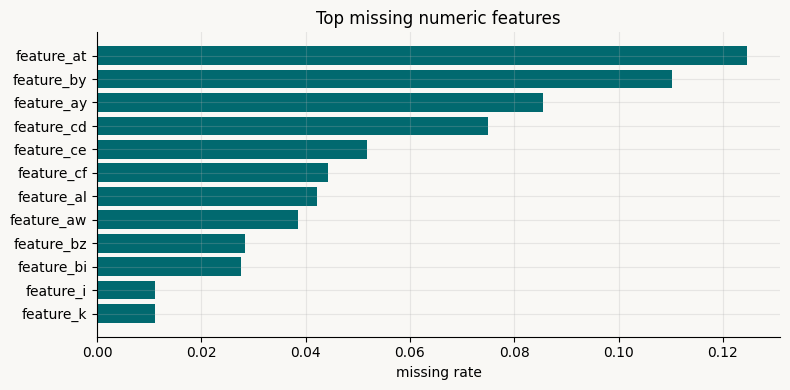

In [6]:
top_plot = missing_table.head(12).sort_values("missing_rate")
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_plot["feature"], top_plot["missing_rate"], color=TEAL)
ax.set_title("Top missing numeric features")
ax.set_xlabel("missing rate")
plt.tight_layout()
plt.show()

In [7]:
# check for dublicate rows based on key columns
duplicate_rows = int(df.duplicated(key_cols).sum())
print(f"duplicate_rows={duplicate_rows}")


duplicate_rows=0


In [8]:
# check for monotonicity violations 
if np.issubdtype(df_sorted[TS_COL].dtype, np.datetime64):
    monotonic_violations = int((ts_diff < pd.Timedelta(0)).fillna(False).sum())
else:
    monotonic_violations = int((pd.to_numeric(ts_diff, errors="coerce") < 0).fillna(False).sum())
print(f"monotonic_violations={monotonic_violations}")


monotonic_violations=0


In [9]:
# check for constant numeric features
constant_features = [c for c in num_features if df[c].nunique(dropna=True) <= 1]
print(f"constant_numeric_features={len(constant_features)}")


constant_numeric_features=0


## 2.1 Target and Horizon Overview

Weighted mean target per horizon:
  horizon   1  weighted_mean=-0.000006  std=11.6997
  horizon   3  weighted_mean=-0.000004  std=19.3612
  horizon  10  weighted_mean=-0.000044  std=33.8421
  horizon  25  weighted_mean=-0.000070  std=52.8233


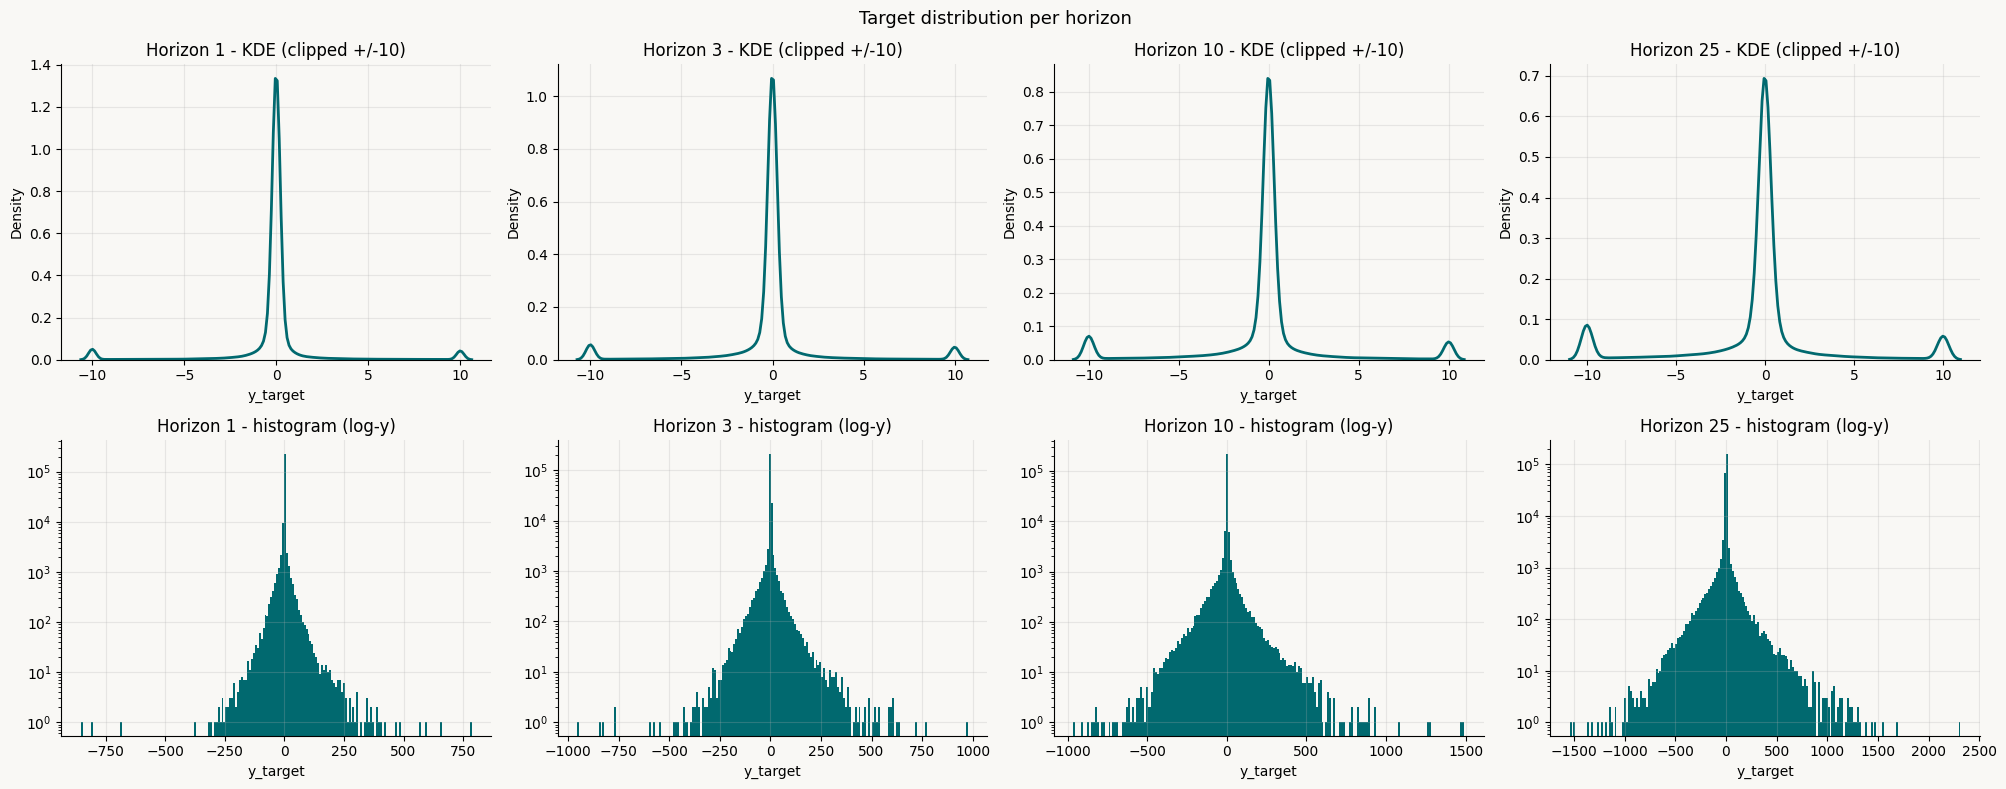

In [10]:
horizons = sorted(pd.unique(df[HORIZON_COL]).tolist())

print("Weighted mean target per horizon:")
rows = []
for h in horizons:
    sub = df[df[HORIZON_COL] == h]
    w = pd.to_numeric(sub[WEIGHT], errors="coerce").fillna(0.0)
    y = pd.to_numeric(sub[TARGET], errors="coerce")
    den = w.sum()
    wm = float((w * y).sum() / den) if den > 0 else np.nan
    ys = y.std()
    print(f"  horizon {int(h):3d}  weighted_mean={wm:.6f}  std={ys:.4f}")
    rows.append({"horizon": int(h), "weighted_mean": wm, "std": ys, "n_rows": len(sub)})

horizon_summary = pd.DataFrame(rows)

fig, axes = plt.subplots(2, len(horizons), figsize=(5 * len(horizons), 8), squeeze=False)
for i, h in enumerate(horizons):
    sub = pd.to_numeric(df.loc[df[HORIZON_COL] == h, TARGET], errors="coerce").dropna()
    if len(sub) > 250000:
        sub = sub.sample(250000, random_state=SEED)

    clipped = sub.clip(-10, 10)
    if len(clipped) > 1:
        sns.kdeplot(clipped, ax=axes[0, i], color=TEAL, lw=2)
    axes[0, i].set_title(f"Horizon {h} - KDE (clipped +/-10)")
    axes[0, i].set_xlabel(TARGET)

    axes[1, i].hist(sub, bins=200, color=TEAL, log=True)
    axes[1, i].set_title(f"Horizon {h} - histogram (log-y)")
    axes[1, i].set_xlabel(TARGET)

plt.suptitle("Target distribution per horizon", fontsize=13)
plt.tight_layout()
plt.show()

## 2.2 Numeric feature diagnostics

Features with excess kurtosis > 50: 38
                 skew     kurtosis
feature_bi  72.249746  7706.086756
feature_ak  20.930848   978.577788
feature_ag  22.038448   797.136264
feature_ba  21.781533   686.625780
feature_aa  12.167774   496.853742
feature_by -15.121651   495.939012
feature_az  12.739819   308.272524
feature_bc  12.638818   293.787408
feature_o   13.733275   287.998094
feature_p   11.007026   285.968981
feature_al   5.071053   277.890287
feature_bz -11.409549   271.572115
feature_cd -10.537603   253.727501
feature_bb  12.172382   222.657357
feature_ca  -9.699978   215.028785
feature_ce  -7.825975   212.124184
feature_au  11.314991   208.648370
feature_aw  10.134159   200.551486
feature_cc  -8.751689   190.208178
feature_q   10.163458   183.148420


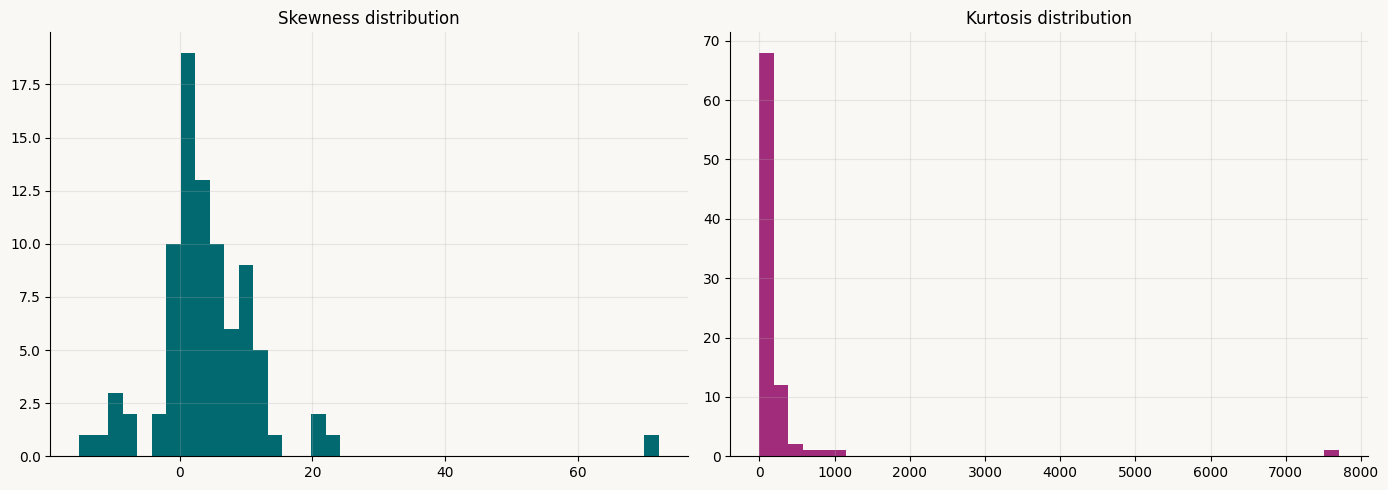

In [11]:

if len(num_features) == 0:
    skew_kurt = pd.DataFrame(columns=["skew", "kurtosis"])
    print("No numeric features for diagnostics")
else:
    diag_source = df_eda[num_features].apply(pd.to_numeric, errors="coerce")
    skew_kurt = pd.DataFrame({
        "skew": diag_source.skew(),
        "kurtosis": diag_source.kurtosis(),
    }).sort_values("kurtosis", ascending=False)

    flagged = skew_kurt[skew_kurt["kurtosis"] > 50]
    print(f"Features with excess kurtosis > 50: {len(flagged)}")
    print(flagged.head(20).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(skew_kurt["skew"].dropna(), bins=40, color=TEAL)
    axes[0].set_title("Skewness distribution")
    axes[1].hist(skew_kurt["kurtosis"].replace([np.inf, -np.inf], np.nan).dropna(), bins=40, color=MAROON)
    axes[1].set_title("Kurtosis distribution")
    plt.tight_layout()
    plt.show()

    

### 2.2.1 Most Extreme Feature 

Feature audit: feature_bi
count=5189982 | mean=22.208468 | std=378.650536 | min=0.000000 | max=66063.215575
skew=77.8666 | kurtosis=9230.4495 | pct_zero=5.40%
count    5.189982e+06
mean     2.220847e+01
std      3.786505e+02
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
25%      1.792965e-01
50%      5.875497e-01
75%      8.098222e+00
95%      3.932133e+01
99%      2.170649e+02
max      6.606322e+04


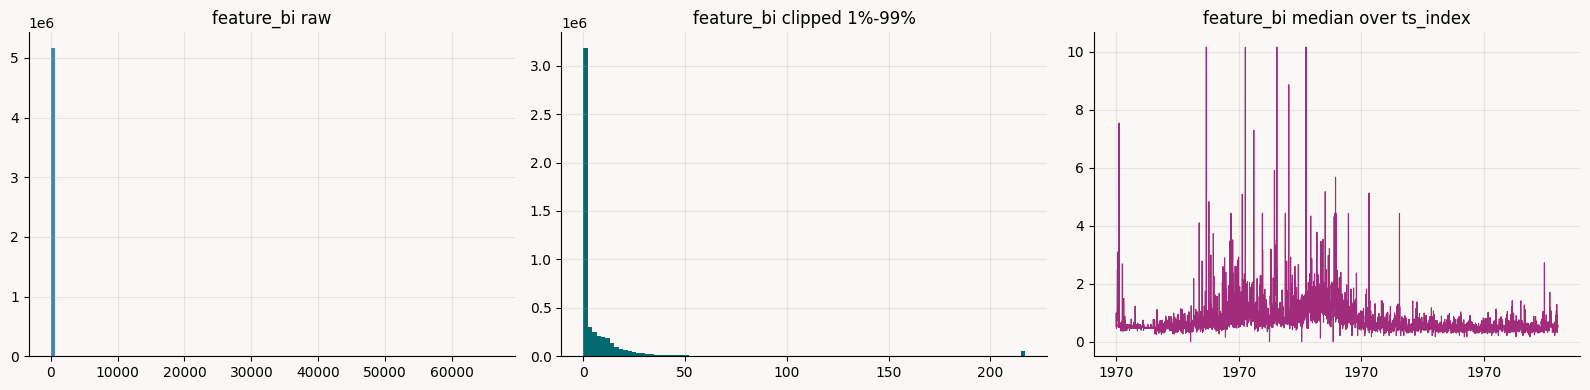

In [12]:
inspect_feature = skew_kurt.index[0] if len(skew_kurt) > 0 else num_features[0]
s = pd.to_numeric(df[inspect_feature], errors="coerce").dropna()

print(f"Feature audit: {inspect_feature}")
print(f"count={len(s)} | mean={s.mean():.6f} | std={s.std():.6f} | min={s.min():.6f} | max={s.max():.6f}")
print(f"skew={s.skew():.4f} | kurtosis={s.kurtosis():.4f} | pct_zero={(s==0).mean()*100:.2f}%")
print(s.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_string())
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(s, bins=100, color="steelblue")
axes[0].set_title(f"{inspect_feature} raw")
lo, hi = s.quantile(0.01), s.quantile(0.99)
axes[1].hist(s.clip(lo, hi), bins=100, color=TEAL)
axes[1].set_title(f"{inspect_feature} clipped 1%-99%")
med = pd.to_numeric(df[[TS_COL, inspect_feature]].groupby(TS_COL)[inspect_feature].median(), errors="coerce")
axes[2].plot(med.index, med.values, color=MAROON, lw=0.8)
axes[2].set_title(f"{inspect_feature} median over {TS_COL}")
plt.tight_layout()
plt.show()

## 2.3 Numeric feature diagnostics

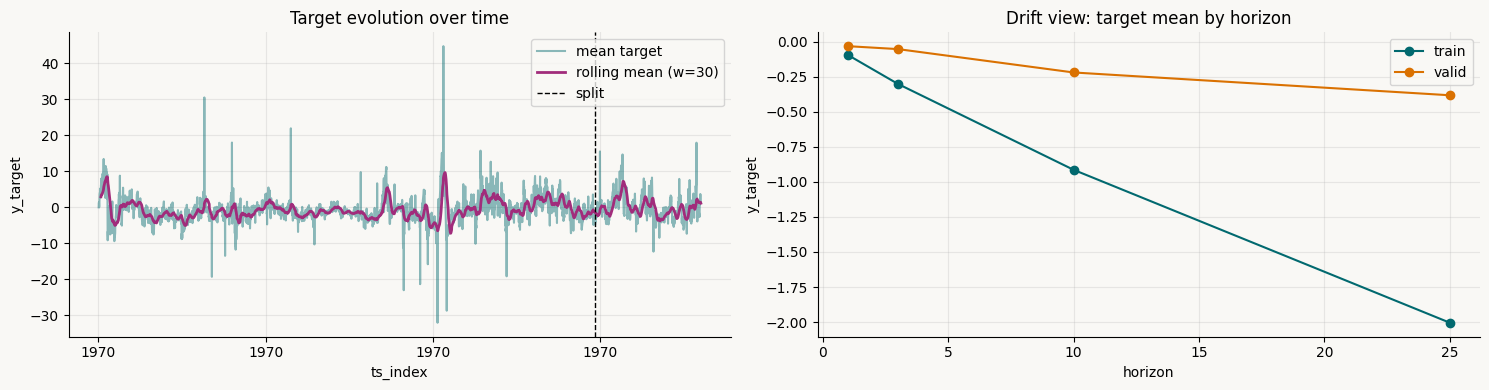

In [13]:
# ensure split exists even if this cell is run before the dedicated split cell
if "split" not in df.columns:
    time_values = np.asarray(df[TS_COL])
    time_values = np.sort(time_values[~pd.isna(time_values)])
    if len(time_values) >= 5:
        split_idx = max(1, int(0.8 * len(time_values)) - 1)
        split_time = time_values[split_idx]
    else:
        split_time = pd.to_numeric(df[TS_COL], errors="coerce").dropna().quantile(0.8)
    df["split"] = np.where(df[TS_COL] <= split_time, "train", "valid")
elif "split_time" not in globals():
    train_mask = df["split"].astype(str).str.lower().eq("train")
    split_time = df.loc[train_mask, TS_COL].max() if train_mask.any() else pd.to_numeric(df[TS_COL], errors="coerce").dropna().quantile(0.8)

target_by_time = pd.to_numeric(df.groupby(TS_COL)[TARGET].mean().sort_index(), errors="coerce")
window = max(5, min(30, len(target_by_time) // 20 if len(target_by_time) >= 20 else 5))
rolling_target = target_by_time.rolling(window=window, min_periods=max(2, window // 2)).mean()

# split-horizon target view
split_h_target = (
    df.groupby([HORIZON_COL, "split"])[TARGET]
      .mean()
      .reset_index()
      .pivot(index=HORIZON_COL, columns="split", values=TARGET)
      .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(target_by_time.index, target_by_time.values, color=TEAL, alpha=0.45, label="mean target")
axes[0].plot(rolling_target.index, rolling_target.values, color=MAROON, lw=2, label=f"rolling mean (w={window})")
axes[0].axvline(split_time, color="black", ls="--", lw=1, label="split")
axes[0].set_title("Target evolution over time")
axes[0].set_xlabel(TS_COL)
axes[0].set_ylabel(TARGET)
axes[0].legend()

if set(["train", "valid"]).issubset(split_h_target.columns):
    axes[1].plot(split_h_target.index, split_h_target["train"], marker="o", color=TEAL, label="train")
    axes[1].plot(split_h_target.index, split_h_target["valid"], marker="o", color=ORANGE, label="valid")
    axes[1].set_title("Drift view: target mean by horizon")
    axes[1].legend()
else:
    split_h_target.plot(marker="o", ax=axes[1])
    axes[1].set_title("Target mean by horizon and split")

axes[1].set_xlabel(HORIZON_COL)
axes[1].set_ylabel(TARGET)
plt.tight_layout()
plt.show()


# 3 Diagnostics

## 3.1 Sample time series panel

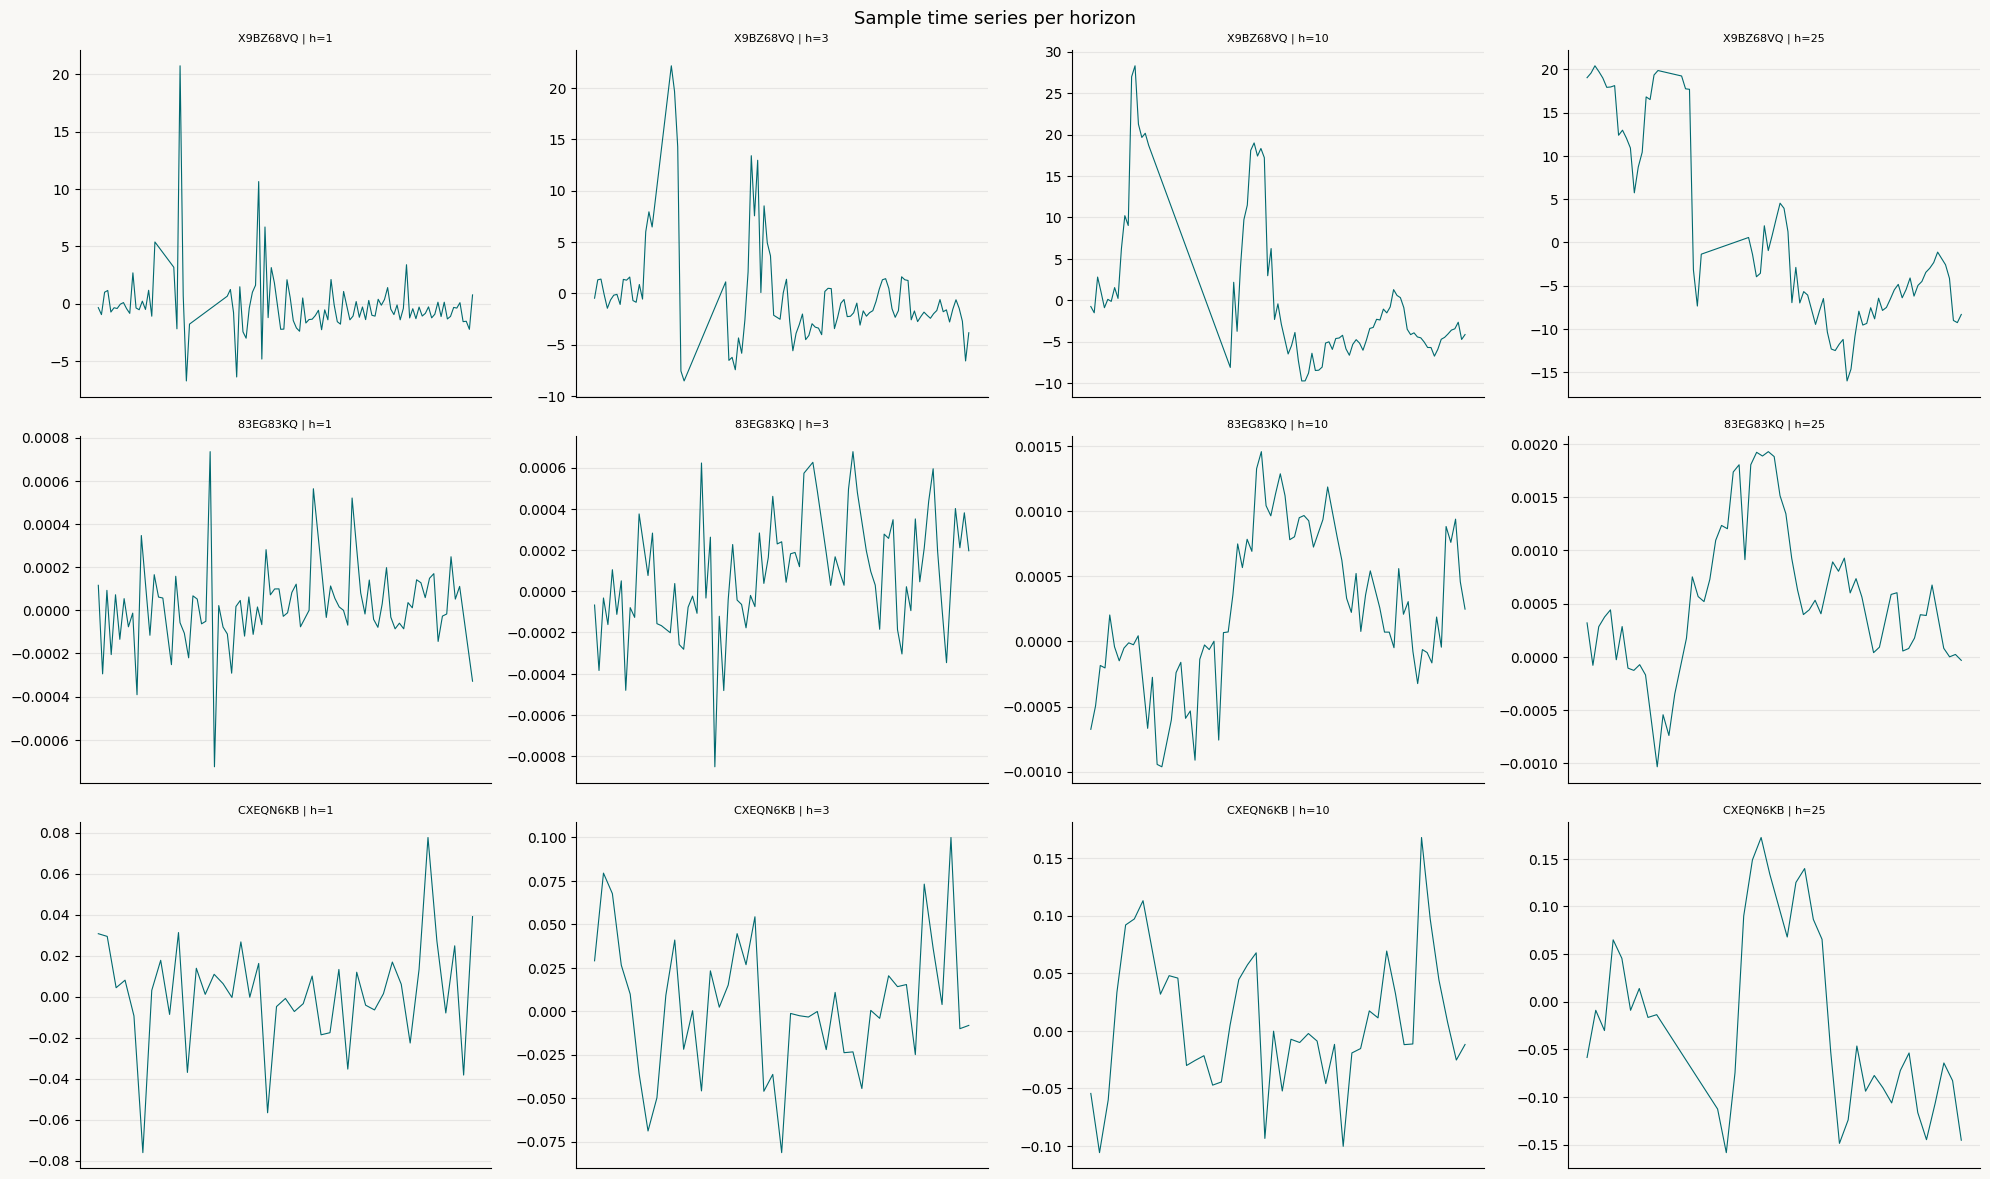

In [14]:

if all(c in df.columns for c in ["code", "sub_code", "sub_category"]):
    key_df = df[["code", "sub_code", "sub_category"]].drop_duplicates()
    n_keys = min(3, len(key_df))
    sample_ids = key_df.sample(n_keys, random_state=SEED)

    fig, axes = plt.subplots(n_keys, len(horizons), figsize=(5 * len(horizons), 4 * n_keys), squeeze=False)
    for row_i, (_, sid) in enumerate(sample_ids.iterrows()):
        mask = (
            (df["code"] == sid["code"]) &
            (df["sub_code"] == sid["sub_code"]) &
            (df["sub_category"] == sid["sub_category"])
        )
        for col_i, h in enumerate(horizons):
            sub = df[mask & (df[HORIZON_COL] == h)].sort_values(TS_COL)
            axes[row_i, col_i].plot(sub[TS_COL].values, sub[TARGET].values, color=TEAL, lw=0.8)
            axes[row_i, col_i].set_title(f"{sid['code']} | h={h}", fontsize=8)

    plt.suptitle("Sample time series per horizon", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Sample series panel skipped (code/sub_code/sub_category not available)")

## 3.2 Investigate

In [15]:
feature_cols = [c for c in df.columns if c.startswith("feature_")]

rows = []

for c in feature_cols:
    s = df[c].dropna()

    if len(s) == 0:
        continue

    rows.append({
        "feature": c,
        "mean_abs": s.abs().mean(),
        "std": s.std(),
        "range": s.max() - s.min(),
        "iqr": s.quantile(0.75) - s.quantile(0.25),
        "q95_q05_range": s.quantile(0.95) - s.quantile(0.05),
        "pct_near_zero": (s.abs() < 1e-4).mean() * 100,
        "n_unique_rounded": s.round(6).nunique()
    })

feature_check = pd.DataFrame(rows)

small_low_variation = feature_check[
    (feature_check["mean_abs"] < 0.10) &
    (
        (feature_check["std"] < 1e-2) |
        (feature_check["q95_q05_range"] < 1e-2) |
        (feature_check["n_unique_rounded"] <= 5) |
        (feature_check["pct_near_zero"] > 99)
    )
].sort_values(["std", "q95_q05_range"]) # hard-coded thresholds (via trial and error)

display(small_low_variation.round(7))

,feature,mean_abs,std,range,iqr,q95_q05_range,pct_near_zero,n_unique_rounded
9,feature_j,0.001662,0.002917,0.108760,0.001943,0.006462,18.243688,13657
10,feature_k,0.002480,0.003510,0.023593,0.003981,0.010023,16.467316,16327
8,feature_i,0.005408,0.005883,0.049242,0.008584,0.016399,4.049550,24419
7,feature_h,0.005912,0.007924,0.110952,0.010096,0.021014,0.350486,29201


## 3.3 Keep track of suspect features

In [16]:
suspect_features = small_low_variation["feature"].tolist()
print(suspect_features)

['feature_j', 'feature_k', 'feature_i', 'feature_h']


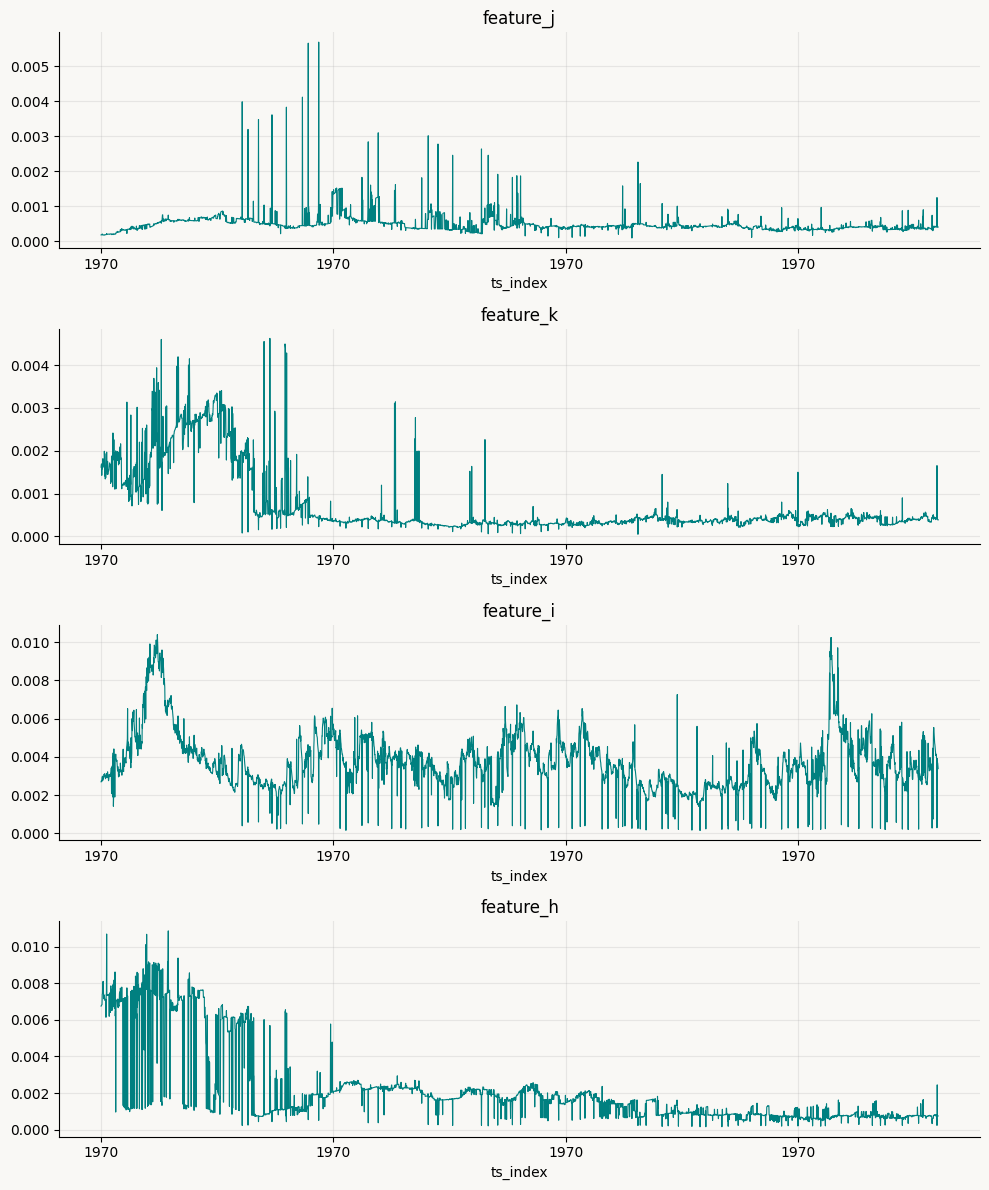

In [17]:
fig, axes = plt.subplots(len(suspect_features), 1,
                         figsize=(10, 3 * len(suspect_features)),
                         squeeze=False)

for i, col in enumerate(suspect_features):
    med = df.groupby(TS_COL)[col].median()
    axes[i, 0].plot(med.index, med.values, color="teal", lw=0.8)
    axes[i, 0].set_title(col)
    axes[i, 0].set_xlabel(TS_COL)

plt.tight_layout()
plt.show()

### 3.3.1 Double check suspect features

In [18]:
check_cols = ["feature_j", "feature_k", "feature_i", "feature_h"]

rows = []
for c in check_cols:
    tmp = df[[c, "y_target"]].dropna()
    rows.append({
        "feature": c,
        "corr_with_target": tmp[c].corr(tmp["y_target"]),
        "std": tmp[c].std(),
        "pct_zero": (tmp[c] == 0).mean() * 100
    })

pd.DataFrame(rows)

,feature,corr_with_target,std,pct_zero
0,feature_j,0.008325,0.002917,0.000379
1,feature_k,-0.029943,0.003510,0.000000
2,feature_i,0.004683,0.005883,0.000000
3,feature_h,-0.025394,0.007924,0.000379


# 4 Rolling Windows Diagnostics

## 4.1 STD

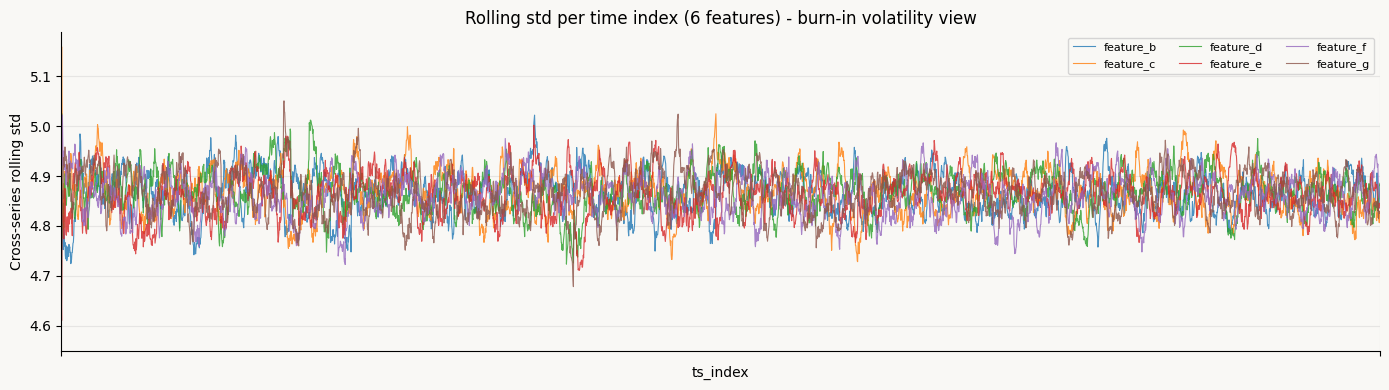

In [19]:
# volatility view (rolling std) for features with burn-in check
if len(num_features) >= 6:
    # if np.issubdtype(df[TS_COL].dtype, np.number):
    #     burnin_threshold = int(np.quantile(pd.unique(df[TS_COL].dropna()), 0.1))
    # else:
    #     burnin_threshold = split_time

    fig, ax = plt.subplots(figsize=(14, 4))

    plotted = 0 # plotting some potentially useful features
    for col in num_features:
        if col == "feature_a": # had to hard code it, plotted afterwards
            continue

        s = pd.to_numeric(df_eda[col], errors="coerce")
        if s.notna().sum() == 0:
            continue

        tmp = pd.DataFrame({TS_COL: df_eda[TS_COL], col: s}).dropna()
        if len(tmp) == 0:
            continue

        roll_std = tmp.groupby(TS_COL)[col].std().rolling(20, min_periods=1).mean()
        if roll_std.notna().sum() == 0:
            continue

        roll_std.plot(ax=ax, lw=0.8, label=col, alpha=0.8)

        plotted += 1
        if plotted == 6:
            break

    # ax.axvline(burnin_threshold, color="red", ls="--", lw=1.5, label=f"ts={burnin_threshold}")
    ax.set_title("Rolling std per time index (6 features) - burn-in volatility view")
    ax.set_xlabel(TS_COL)
    ax.set_ylabel("Cross-series rolling std")
    ax.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()



### 4.1.1 Check one feature (different scale)

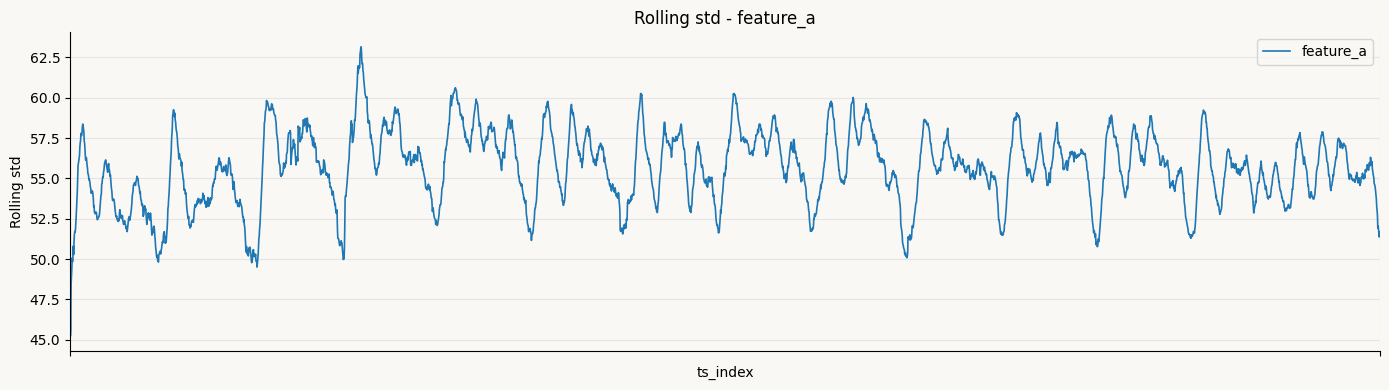

In [20]:
if "feature_a" in df_eda.columns: # plotted here because of its values/scale 
    s = pd.to_numeric(df_eda["feature_a"], errors="coerce")
    tmp = pd.DataFrame({TS_COL: df_eda[TS_COL], "feature_a": s}).dropna()

    if len(tmp) > 0:
        roll_std_a = tmp.groupby(TS_COL)["feature_a"].std().rolling(20, min_periods=1).mean()

        fig, ax = plt.subplots(figsize=(14, 4))
        roll_std_a.plot(ax=ax, lw=1.2, label="feature_a")

        # ax.axvline(burnin_threshold, color="red", ls="--", lw=1.5, label=f"ts={burnin_threshold}")
        ax.set_title("Rolling std - feature_a")
        ax.set_xlabel(TS_COL)
        ax.set_ylabel("Rolling std")
        ax.legend()
        plt.tight_layout()
        plt.show()

if "code" in df.columns:
    rep_code = df["code"].value_counts().idxmax()
    rep = df[(df["code"] == rep_code) & (df[HORIZON_COL] == horizons[0])].sort_values(TS_COL).head(500)
else:
    rep = df[df[HORIZON_COL] == horizons[0]].sort_values(TS_COL).head(500)

y = pd.to_numeric(rep[TARGET], errors="coerce").dropna().values



### 4.1.2 More Plots

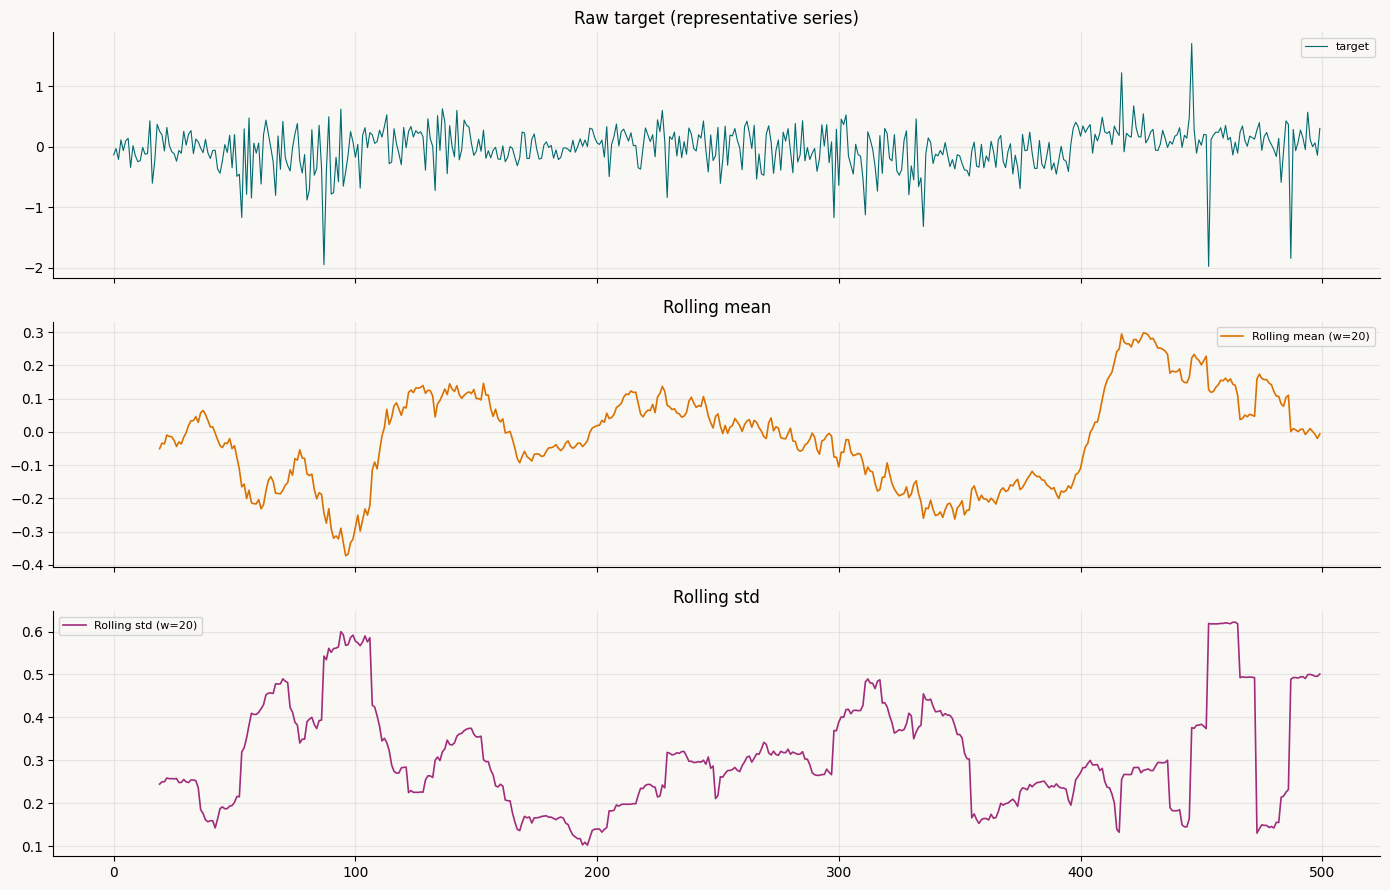

In [21]:
roll_mean = pd.Series(y).rolling(20).mean()
roll_std = pd.Series(y).rolling(20).std()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(y, color=TEAL, lw=0.8, label="target")
axes[0].set_title("Raw target (representative series)")
axes[1].plot(roll_mean, color=ORANGE, lw=1.2, label="Rolling mean (w=20)")
axes[1].set_title("Rolling mean")
axes[2].plot(roll_std, color=MAROON, lw=1.2, label="Rolling std (w=20)")
axes[2].set_title("Rolling std")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


# 5 ACF/PACF

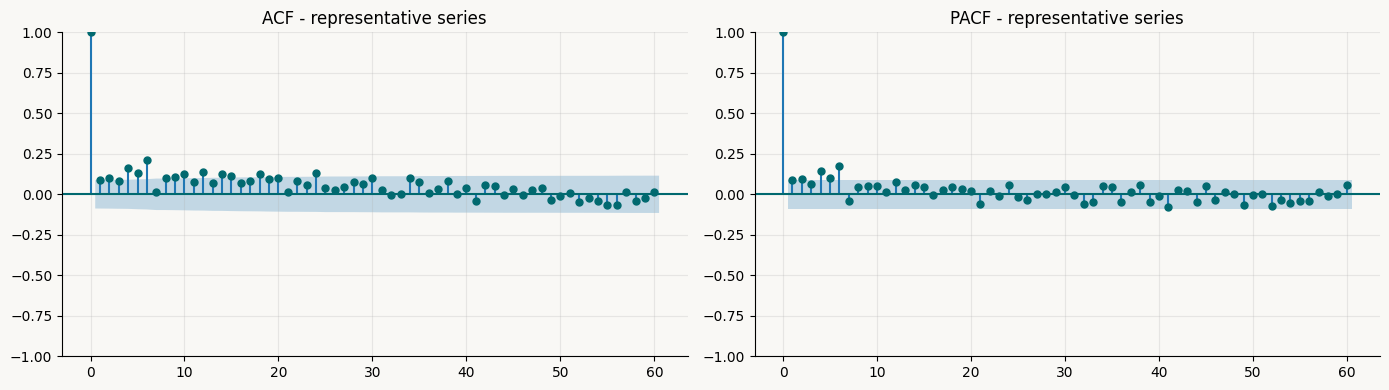

In [22]:
if HAS_STATSMODELS:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_acf(y, lags=min(60, len(y)//2 - 1), ax=axes[0], color=TEAL)
        axes[0].set_title("ACF - representative series")
        plot_pacf(y, lags=min(60, len(y)//2 - 1), ax=axes[1], color=TEAL, method="ywm")
        axes[1].set_title("PACF - representative series")
        plt.tight_layout()
        plt.show()

## 5.1 Correlation with $y_{target}$

In [23]:
feature_cols = [c for c in df.columns if c.startswith("feature_")]

corr_rows = []

for c in feature_cols:
    tmp = df[[c, "y_target"]].dropna()

    corr_rows.append({
        "feature": c,
        "corr_with_y_target": tmp[c].corr(tmp["y_target"]),
        "abs_corr": abs(tmp[c].corr(tmp["y_target"])),
        "n_obs": len(tmp)
    })

feature_target_corr = (
    pd.DataFrame(corr_rows)
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

display(feature_target_corr.round(4))


,feature,corr_with_y_target,abs_corr,n_obs
0,feature_bz,0.0905,0.0905,5185692
1,feature_cd,0.0860,0.0860,4937300
2,feature_af,-0.0735,0.0735,5329288
3,feature_u,-0.0701,0.0701,5330292
4,feature_bo,-0.0582,0.0582,5337414
...,...,...,...,...
81,feature_bi,0.0005,0.0005,5189982
82,feature_g,-0.0002,0.0002,5337414
83,feature_d,0.0001,0.0001,5337414
84,feature_b,-0.0001,0.0001,5337414


## 5.2 Update the suspect columns

In [24]:
threshold = 0.001

drop_cols = feature_target_corr.loc[
    feature_target_corr["abs_corr"] < threshold, "feature"
].tolist()

print("Columns to drop:", len(drop_cols))
print(f"New suspect features: {drop_cols}")

suspect_features += drop_cols
suspect_features = list(set(suspect_features)) # unique feature names only
print(f"All suspect features: {suspect_features}")
print(f"Total suspect features: {len(suspect_features)}")


Columns to drop: 8
New suspect features: ['feature_ak', 'feature_e', 'feature_c', 'feature_bi', 'feature_g', 'feature_d', 'feature_b', 'feature_f']
All suspect features: ['feature_e', 'feature_h', 'feature_c', 'feature_g', 'feature_ak', 'feature_k', 'feature_bi', 'feature_d', 'feature_j', 'feature_i', 'feature_f', 'feature_b']
Total suspect features: 12


## 5.3 Check for periodic frequencies

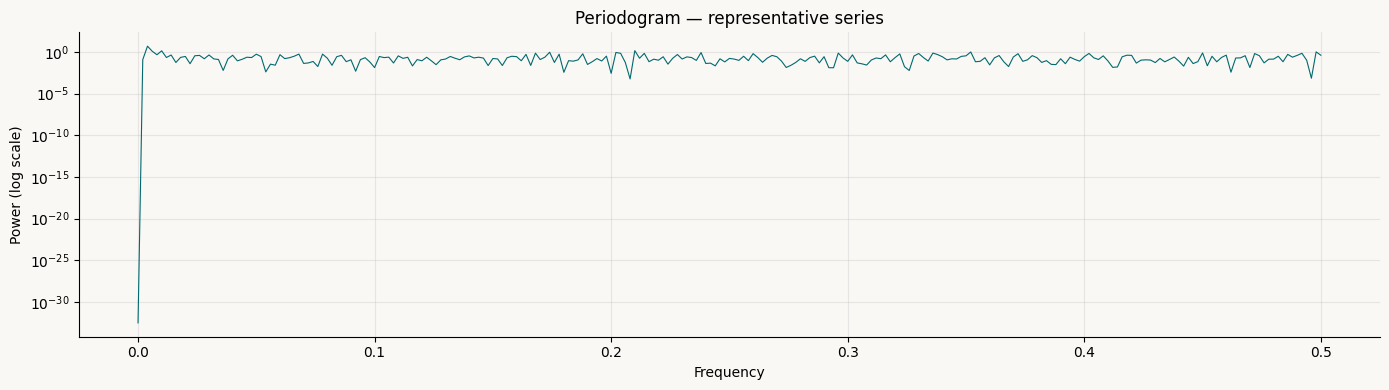

In [25]:
from scipy.signal import periodogram

freqs, power = periodogram(y)

fig, ax = plt.subplots(figsize=(14, 4))
ax.semilogy(freqs, power, color=TEAL, lw=0.8)
ax.set_title("Periodogram — representative series")
ax.set_xlabel("Frequency")
ax.set_ylabel("Power (log scale)")
plt.tight_layout()
plt.show()

## 5.4 Drop the suspect columns

To not overload the future processes

In [26]:
# define feature_cols for the global feature-target correlation cell
meta_cols = [c for c in [TARGET, WEIGHT, HORIZON_COL, TS_COL, "id", "code", "sub_code", "sub_category", "split"] if c in df.columns]
num_features = [c for c in df.select_dtypes(include="number").columns if c not in meta_cols]

feature_cols = [c for c in num_features if str(c).startswith("feature_") and c not in suspect_features]
df.drop(columns=[c for c in feature_cols if c in suspect_features], inplace=True) # drop globally

print(f"n_feature_cols={len(feature_cols)}")
print(feature_cols[:10])


n_feature_cols=74
['feature_a', 'feature_l', 'feature_m', 'feature_n', 'feature_o', 'feature_p', 'feature_q', 'feature_r', 'feature_s', 'feature_t']


# 6 Spearman IC

## 6.1 Horizon + Heatmap

Top 20 features by mean absolute IC across horizons:
horizon            1         3        10        25  mean_abs_IC
feature_bz  0.085692  0.083628  0.110757  0.134374     0.103613
feature_by  0.087555  0.080752  0.106074  0.129876     0.101065
feature_ca  0.081118  0.081054  0.103681  0.125416     0.097817
feature_am -0.079560 -0.074870 -0.102156 -0.129746     0.096583
feature_u  -0.080525 -0.077512 -0.100217 -0.123087     0.095335
feature_cd  0.078708  0.079630  0.101095  0.120310     0.094936
feature_cc  0.078752  0.077578  0.100629  0.118860     0.093955
feature_ao -0.074982 -0.074350 -0.100352 -0.124277     0.093490
feature_cb  0.075408  0.075334  0.095334  0.119248     0.091331
feature_az  0.072885  0.074643  0.095772  0.120143     0.090861
feature_bq  0.073311  0.073923  0.096076  0.118343     0.090413
feature_ag -0.076665 -0.071597 -0.093059 -0.113898     0.088805
feature_bp  0.068255  0.068950  0.094109  0.115007     0.086580
feature_ap -0.069711 -0.069765 -0.090962 -0.115243 

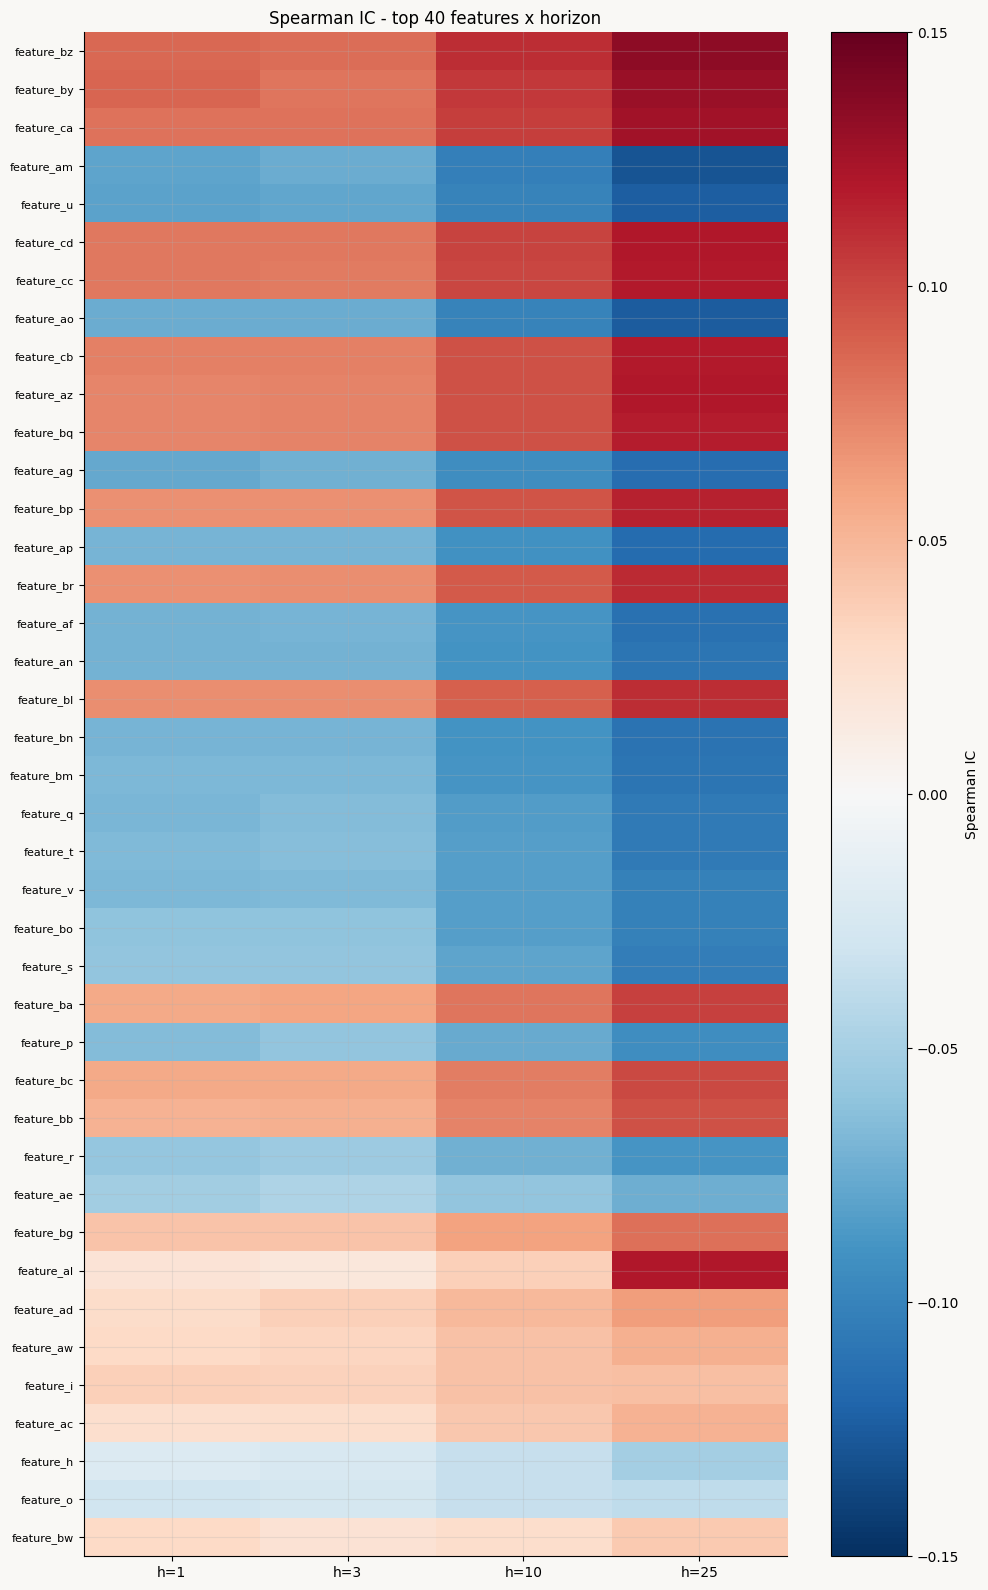

selected_features_total=11
h=1: 8 features
h=3: 8 features
h=10: 8 features
h=25: 8 features


In [27]:
ic_rows = []
MAX_ROWS_PER_H = 300000

for h in horizons:
    sub = df[(df[HORIZON_COL] == h) & (df["split"] == "train")][num_features + [TARGET]].dropna(subset=[TARGET])
    if len(sub) > MAX_ROWS_PER_H:
        sub = sub.sample(MAX_ROWS_PER_H, random_state=SEED)

    row = {"horizon": h}
    for col in num_features:
        x = pd.to_numeric(sub[col], errors="coerce")
        y = pd.to_numeric(sub[TARGET], errors="coerce")
        ok = x.notna() & y.notna()
        if ok.sum() < 100 or x[ok].nunique() <= 1:
            row[col] = np.nan
        else:
            r, _ = spearmanr(x[ok], y[ok])
            row[col] = r
    ic_rows.append(row)

ic_df = pd.DataFrame(ic_rows).set_index("horizon").T
ic_df["mean_abs_IC"] = ic_df.abs().mean(axis=1)
ic_df = ic_df.sort_values("mean_abs_IC", ascending=False)

print("Top 20 features by mean absolute IC across horizons:")
print(ic_df.head(20).to_string())

plot_data = ic_df.drop(columns=["mean_abs_IC"], errors="ignore").head(40)
fig, ax = plt.subplots(figsize=(10, 16))
im = ax.imshow(plot_data.values, aspect="auto", cmap="RdBu_r", vmin=-0.15, vmax=0.15)
ax.set_xticks(range(len(plot_data.columns)))
ax.set_xticklabels([f"h={h}" for h in plot_data.columns])
ax.set_yticks(range(len(plot_data.index)))
ax.set_yticklabels(plot_data.index, fontsize=8)
plt.colorbar(im, ax=ax, label="Spearman IC")
ax.set_title("Spearman IC - top 40 features x horizon")
plt.tight_layout()
plt.show()

# select features per horizon (not one global threshold/ranking)
ic_mat = ic_df.drop(columns=["mean_abs_IC"], errors="ignore")
selected_features_by_horizon = {}
for h in ic_mat.columns:
    top_h = ic_mat[h].abs().sort_values(ascending=False).head(8).index.tolist()
    selected_features_by_horizon[int(h)] = top_h

selected_features = sorted(set(sum(selected_features_by_horizon.values(), [])))
selected_features = [f for f in selected_features if f in num_features]

print(f"selected_features_total={len(selected_features)}")
for h in sorted(selected_features_by_horizon):
    print(f"h={h}: {len(selected_features_by_horizon[h])} features")

## 6.2 Check Flips

features with sign flip (1->25): 9
features with stable sign (1->25): 77


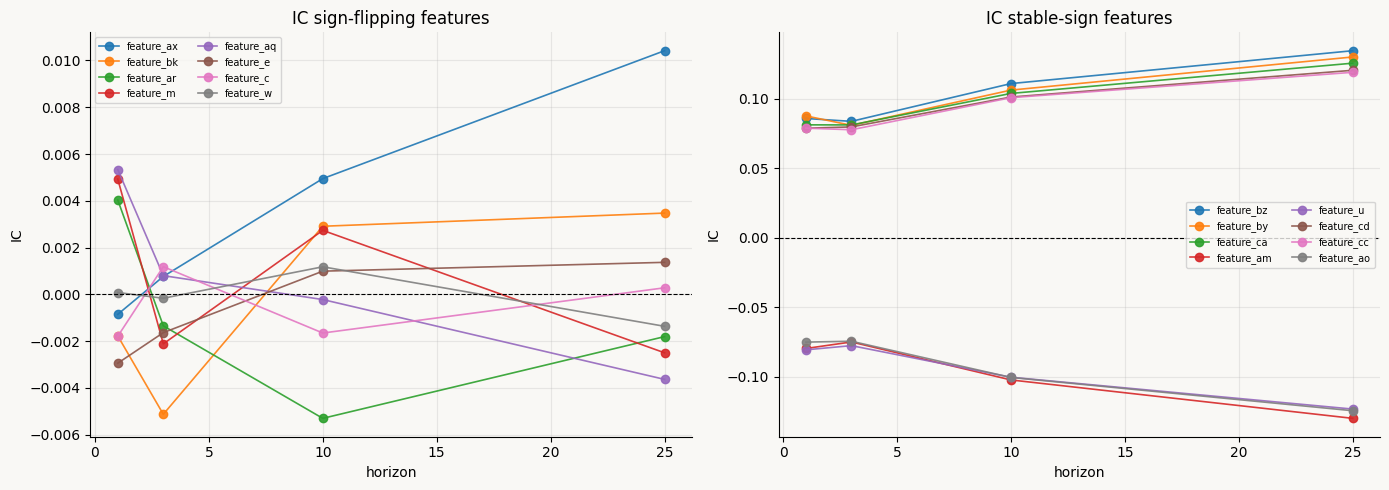

In [28]:
# checking the IC sign
ic_mat = ic_df.drop(columns=["mean_abs_IC"], errors="ignore").copy()

# working per feature to identify sign flips and 
# stable signs across horizons
if len(ic_mat.columns) >= 2:
    h_first = ic_mat.columns[0]
    h_last = ic_mat.columns[-1]

    valid = ic_mat[h_first].notna() & ic_mat[h_last].notna()
    flip = valid & ((ic_mat[h_first] * ic_mat[h_last]) < 0)

    flippers = ic_mat.index[flip].tolist()
    stable = ic_mat.index[valid & (~flip)].tolist()

    score_map = ic_df["mean_abs_IC"].to_dict()
    flip_top = sorted(flippers, key=lambda x: score_map.get(x, 0), reverse=True)[:8]
    stable_top = sorted(stable, key=lambda x: score_map.get(x, 0), reverse=True)[:8]

    print(f"features with sign flip ({h_first}->{h_last}): {len(flippers)}")
    print(f"features with stable sign ({h_first}->{h_last}): {len(stable)}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for f in flip_top:
        axes[0].plot(ic_mat.columns, ic_mat.loc[f, ic_mat.columns], marker="o", lw=1.2, alpha=0.9, label=f)
    axes[0].axhline(0, color="black", lw=0.8, ls="--")
    axes[0].set_title("IC sign-flipping features")
    axes[0].set_xlabel("horizon")
    axes[0].set_ylabel("IC")
    if len(flip_top) > 0:
        axes[0].legend(fontsize=7, ncol=2)

    for f in stable_top:
        axes[1].plot(ic_mat.columns, ic_mat.loc[f, ic_mat.columns], marker="o", lw=1.2, alpha=0.9, label=f)
    axes[1].axhline(0, color="black", lw=0.8, ls="--")
    axes[1].set_title("IC stable-sign features")
    axes[1].set_xlabel("horizon")
    axes[1].set_ylabel("IC")
    if len(stable_top) > 0:
        axes[1].legend(fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough horizons for sign-flip analysis")

# 7 Correlation Matrix (Heatmap)

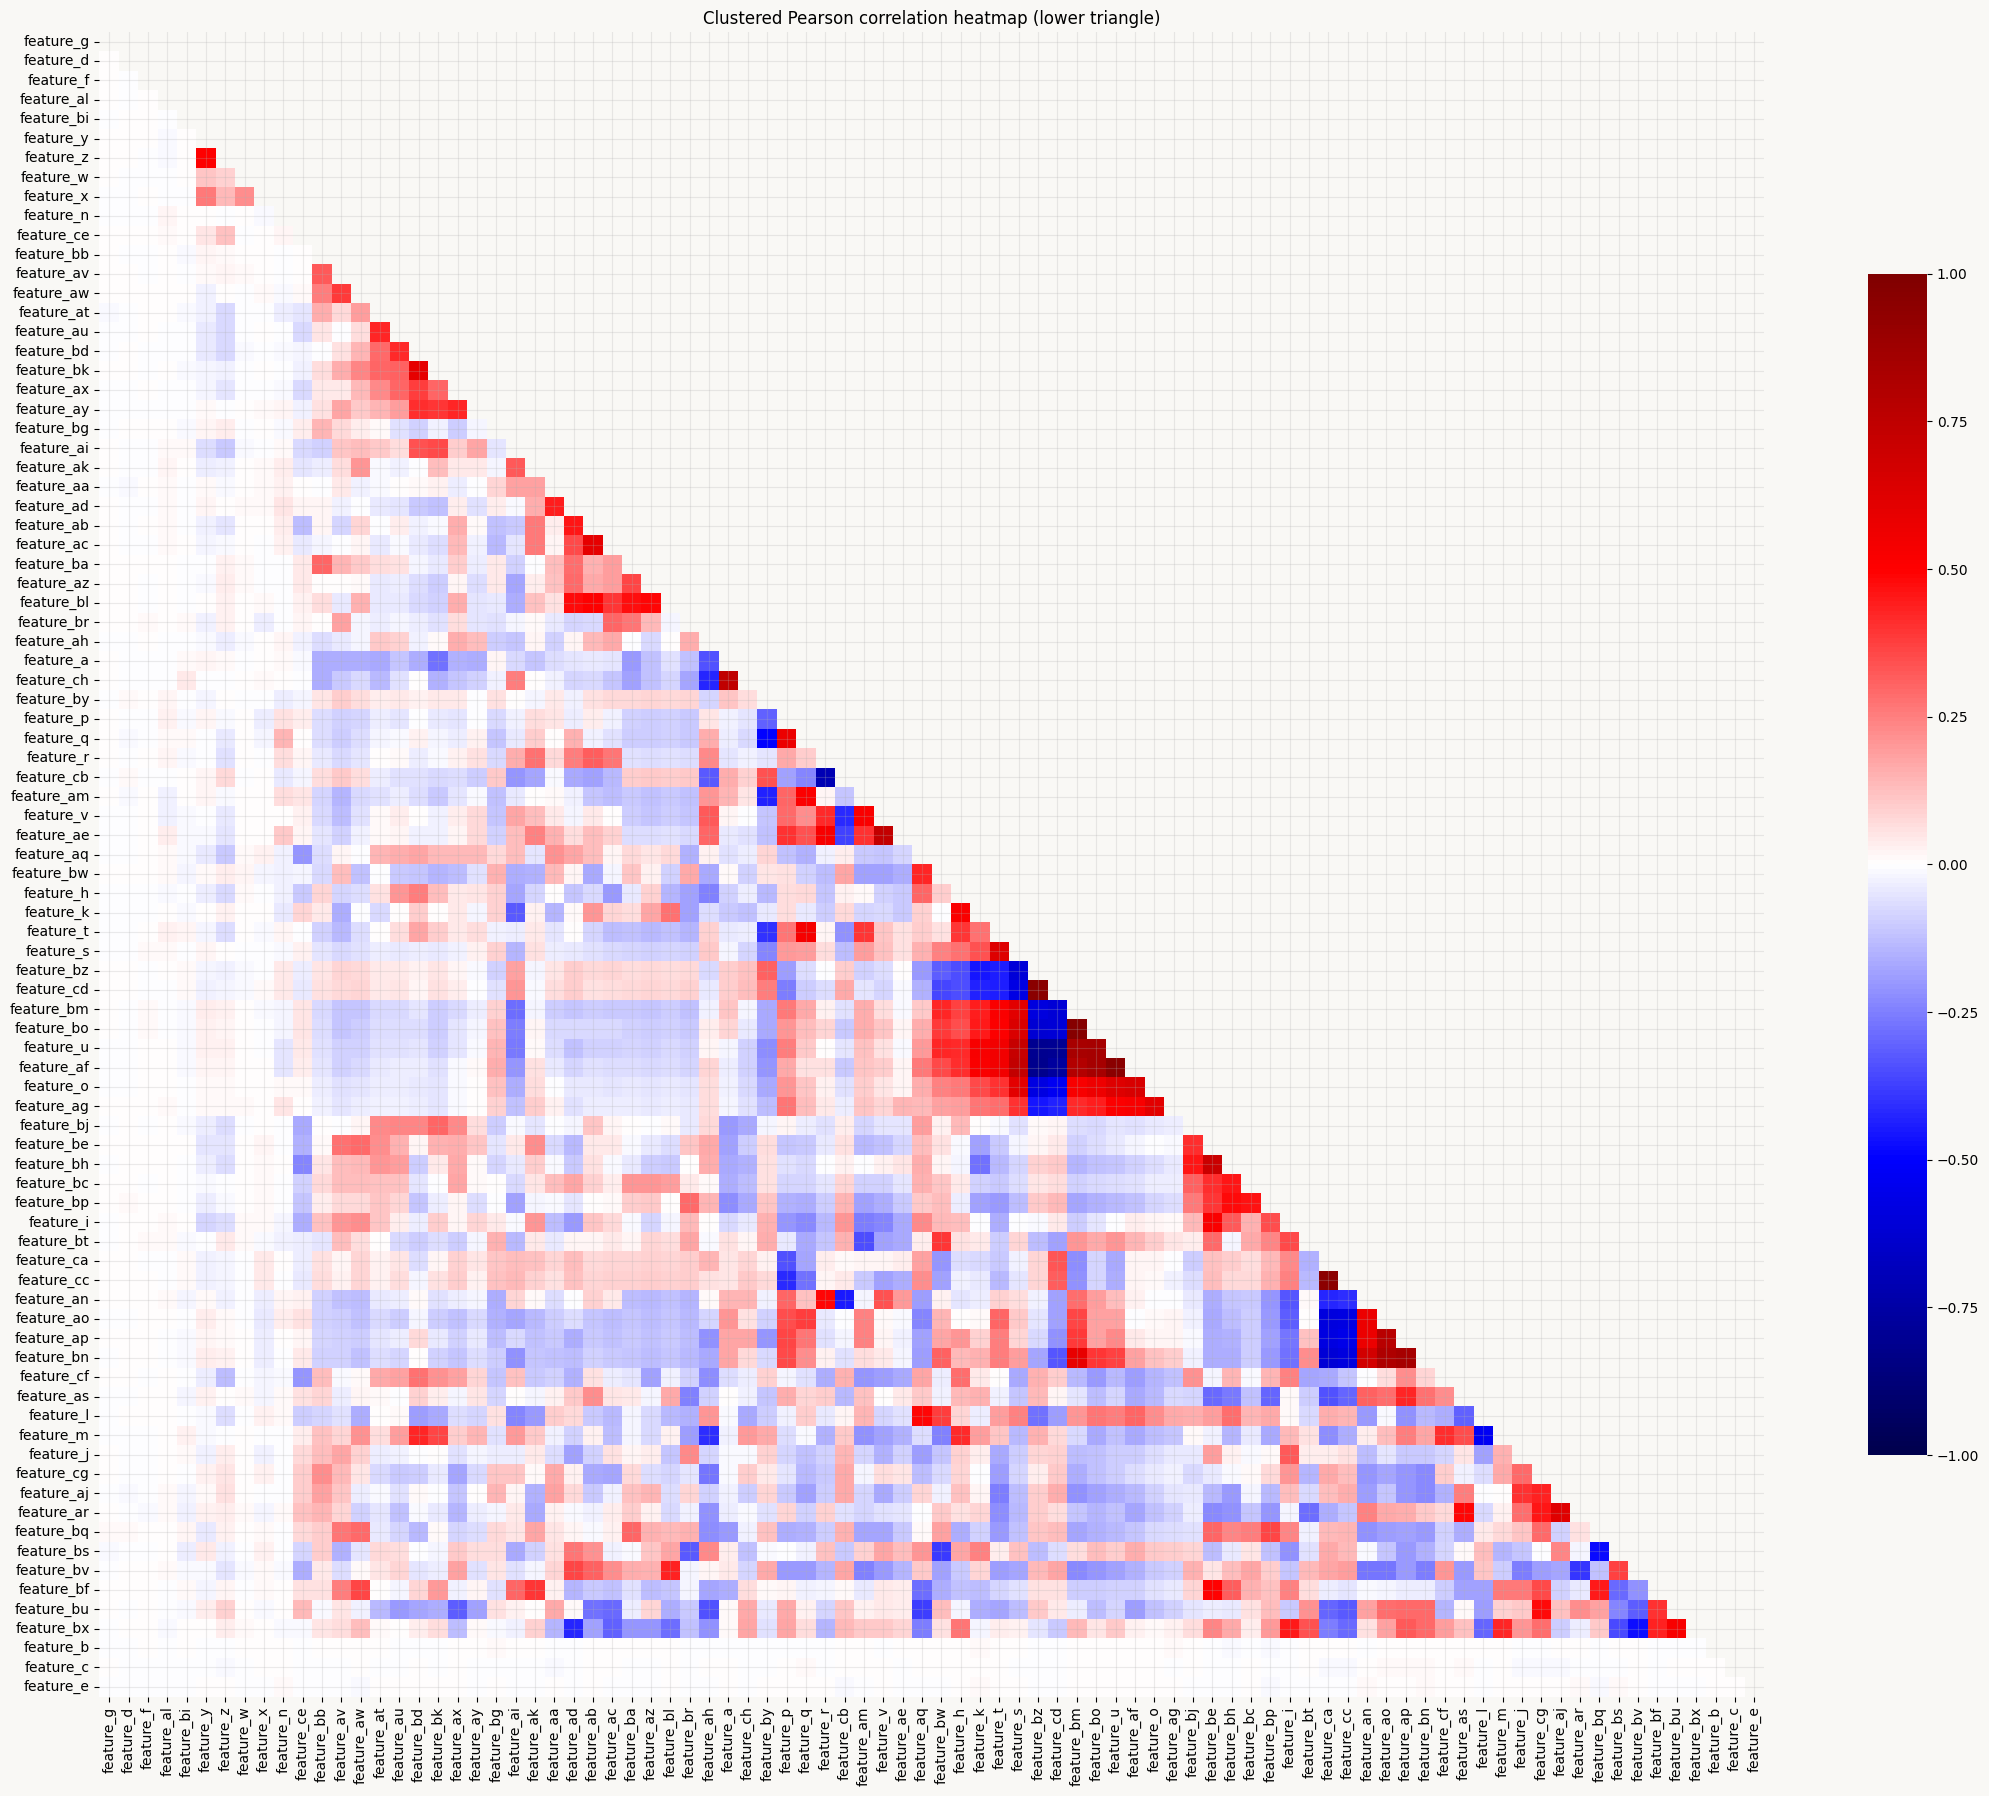

Pairs with |Pearson r| > 0.95: 4
     feat1      feat2  pearson_r    abs_r
feature_bm feature_bo   0.969736 0.969736
 feature_u feature_af   0.957092 0.957092
feature_bz feature_cd   0.953416 0.953416
feature_ca feature_cc   0.951648 0.951648


In [29]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

df_s = df[num_features].dropna().sample(min(50_000, len(df)), random_state=SEED)
pearson_mat = df_s.corr(method="pearson")

dist_arr = (1 - pearson_mat.abs().clip(0, 1)).to_numpy().copy()
np.fill_diagonal(dist_arr, 0)
link  = linkage(squareform(dist_arr.clip(0)), method="average")
order = dendrogram(link, no_plot=True)["leaves"]
p_ord = pearson_mat.iloc[order, order]

fig, ax = plt.subplots(figsize=(22, 20))
mask = np.triu(np.ones_like(p_ord, dtype=bool))
sns.heatmap(p_ord, mask=mask, cmap="seismic", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title("Clustered Pearson correlation heatmap (lower triangle)", fontsize=12)
plt.tight_layout()
plt.show()

upper   = pearson_mat.where(np.triu(np.ones(pearson_mat.shape, dtype=bool), k=1))
hi_corr = (upper.stack()
                .reset_index()
                .rename(columns={"level_0": "feat1", "level_1": "feat2", 0: "pearson_r"})
                .assign(abs_r=lambda x: x["pearson_r"].abs())
                .sort_values("abs_r", ascending=False))
flagged_pairs = hi_corr[hi_corr["abs_r"] > 0.95]
print(f"Pairs with |Pearson r| > 0.95: {len(flagged_pairs)}")
print(flagged_pairs.head(10).to_string(index=False))

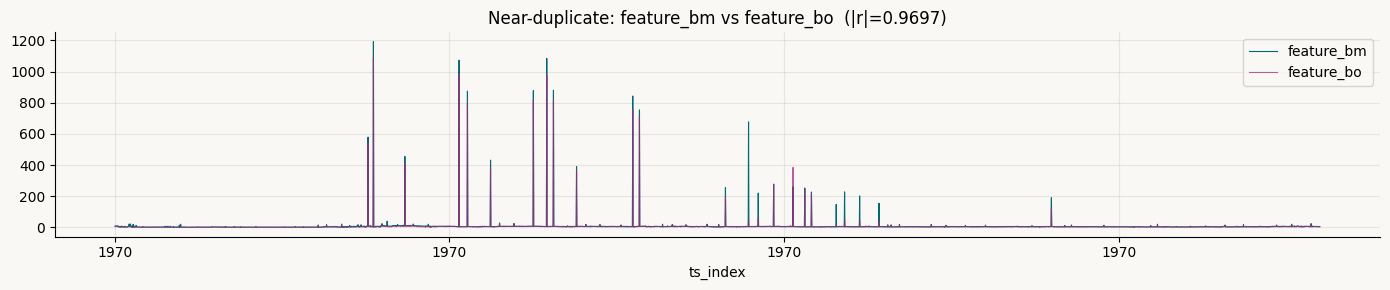

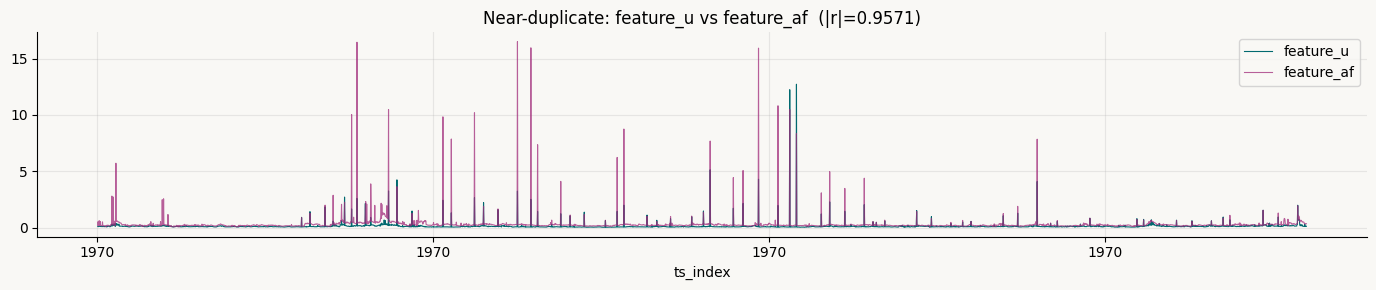

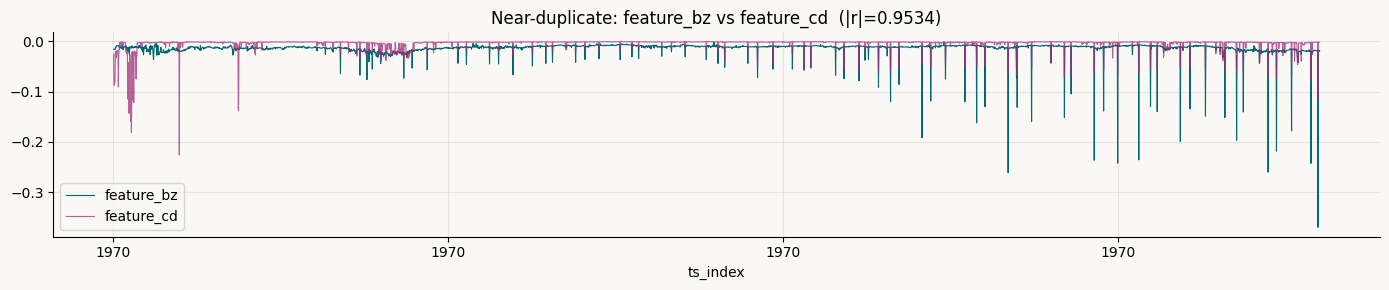

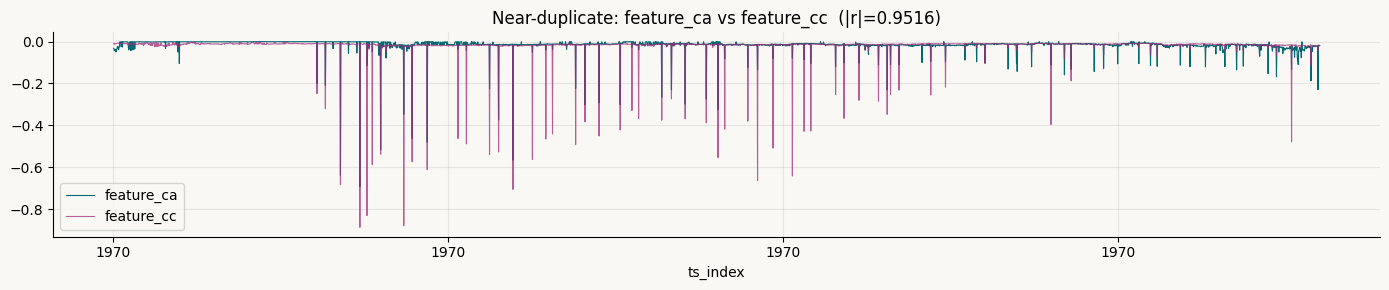

In [30]:
top_pairs = flagged_pairs.head(5)

for _, row in top_pairs.iterrows():
    c1, c2 = row["feat1"], row["feat2"]
    med1 = df.groupby(TS_COL)[c1].median()
    med2 = df.groupby(TS_COL)[c2].median()

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(med1.index, med1.values, lw=0.8, label=c1, color=TEAL)
    ax.plot(med2.index, med2.values, lw=0.8, label=c2, color=MAROON, alpha=0.75)
    ax.set_title(f"Near-duplicate: {c1} vs {c2}  (|r|={row['abs_r']:.4f})")
    ax.set_xlabel("ts_index")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [31]:
pairs = [
    ("feature_bm", "feature_bo"),
    ("feature_u", "feature_af"),
    ("feature_bz", "feature_cd"),
    ("feature_ca", "feature_cc"),
]

rows = []
for f1, f2 in pairs:
    for c in [f1, f2]:
        tmp = df[[c, "y_target"]].dropna()
        rows.append({
            "pair": f"{f1} vs {f2}",
            "feature": c,
            "missing": df[c].isna().sum(),
            "missing_pct": 100 * df[c].isna().mean(),
            "abs_corr_with_y": abs(tmp[c].corr(tmp["y_target"])),
            "skew": df[c].dropna().skew(),
            "kurtosis": df[c].dropna().kurtosis()
        })

pair_compare = pd.DataFrame(rows)
display(pair_compare.round(4))

,pair,feature,missing,missing_pct,abs_corr_with_y,skew,kurtosis
0,feature_bm vs feature_bo,feature_bm,0,0.0000,0.0546,4.5844,23.2763
1,feature_bm vs feature_bo,feature_bo,0,0.0000,0.0582,5.2675,29.6994
2,feature_u vs feature_af,feature_u,7122,0.1334,0.0701,5.7171,37.8265
3,feature_u vs feature_af,feature_af,8126,0.1522,0.0735,6.0574,41.3605
4,feature_bz vs feature_cd,feature_bz,151722,2.8426,0.0905,-11.5055,283.4694
5,feature_bz vs feature_cd,feature_cd,400114,7.4964,0.0860,-10.4429,251.0668
6,feature_ca vs feature_cc,feature_ca,40,0.0007,0.0050,-10.5789,289.7211
7,feature_ca vs feature_cc,feature_cc,2635,0.0494,0.0170,-9.3361,232.6309


## 7.1 Drop the correlated columns

In [32]:
drop_cols = ["feature_bo", "feature_af", "feature_cd", "feature_ca"] # hard coded
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# 8 Split

## 8.1 Time based

In [33]:
time_values = np.asarray(df[TS_COL])
time_values = np.sort(time_values[~pd.isna(time_values)])
if len(time_values) < 5: # used 5 as threshold to respect the 80/20 split and have at least 1 time point in validation
    raise ValueError("Not enough unique time points for time-based split")

split_idx = max(1, int(0.8 * len(time_values)) - 1)
split_time = time_values[split_idx]
df["split"] = np.where(df[TS_COL] <= split_time, "train", "valid")

train_max_time = df.loc[df["split"] == "train", TS_COL].max()
valid_min_time = df.loc[df["split"] == "valid", TS_COL].min()
no_time_leakage = bool(train_max_time <= valid_min_time)

entity_keys = list(set(series_cols + [HORIZON_COL]))
entity_overlap = int(
    df[df["split"] == "train"][entity_keys].drop_duplicates()
    .merge(df[df["split"] == "valid"][entity_keys].drop_duplicates(), on=entity_keys, how="inner")
    .shape[0]
)

print(f"split_time={split_time}")
print(df["split"].value_counts().to_string())
print(f"time_order_ok={no_time_leakage} | train_max_time={train_max_time} | valid_min_time={valid_min_time}")
print(f"entity_overlap_between_splits={entity_overlap} (expected in panel data if time-order respected)")

split_time=1970-01-01T00:00:00.000002967
split
train    4271057
valid    1066357
time_order_ok=True | train_max_time=1970-01-01 00:00:00.000002967 | valid_min_time=1970-01-01 00:00:00.000002968
entity_overlap_between_splits=0 (expected in panel data if time-order respected)


## 8.2 Preparation

In [34]:
# pipeline 
if "split" not in df.columns:
    raise ValueError("Column 'split' is missing. Run the time-based split cell first.")

meta_cols = [c for c in [TARGET, WEIGHT, HORIZON_COL, TS_COL, "split", "id", "code", "sub_code", "sub_category"] if c in df.columns]

num_features = [c for c in df.select_dtypes(include="number").columns if c not in meta_cols] #redefined after the drops

# go for horizon-specific feature selection
if "selected_features" not in globals() or len(selected_features) == 0:
    if "selected_features_by_horizon" in globals() and isinstance(selected_features_by_horizon, dict) and len(selected_features_by_horizon) > 0:
        selected_features = sorted(set(sum(selected_features_by_horizon.values(), [])))
    elif "ic_df" in globals() and len(ic_df) > 0 and "mean_abs_IC" in ic_df.columns:
        selected_features = ic_df.sort_values("mean_abs_IC", ascending=False).head(12).index.tolist()
    elif "feature_target_corr" in globals() and len(feature_target_corr) > 0:
        selected_features = feature_target_corr.head(12)["feature"].tolist()
    else:
        selected_features = num_features[:12]

selected_features = [f for f in selected_features if f in num_features]
if len(selected_features) > 24:
    selected_features = selected_features[:24]
if len(selected_features) == 0:
    raise ValueError("No selected numeric features available for preparation.")

if "series_cols" not in globals() or len(series_cols) == 0:
    series_cols = [c for c in ["id", "code", "sub_code", "sub_category"] if c in df.columns]
if len(series_cols) == 0:
    df["__series_id__"] = 0
    series_cols = ["__series_id__"]

prep_key_cols = list(set(series_cols + [HORIZON_COL]))
prep_cols = list(set(prep_key_cols + [TS_COL, "split", TARGET, WEIGHT] + selected_features))
sort_cols = [c for c in prep_key_cols + [TS_COL] if c in prep_cols]
df_prep = df[prep_cols].copy().sort_values(sort_cols).reset_index(drop=True)

recommend_map = {}

model_features = []
prep_plan_rows = []
transformers = {}

train_mask = df_prep["split"].eq("train")

for f in selected_features:
    raw = pd.to_numeric(df_prep[f], errors="coerce")

    # train-only + horizon-specific quantiles 
    tr_h = df_prep.loc[train_mask, [HORIZON_COL, f]].copy()
    tr_h[f] = pd.to_numeric(tr_h[f], errors="coerce")
    q_h = tr_h.groupby(HORIZON_COL)[f].quantile([0.01, 0.99]).unstack().rename(columns={0.01: "q01", 0.99: "q99"})

    q01_row = df_prep[HORIZON_COL].map(q_h["q01"]) if "q01" in q_h.columns else pd.Series(np.nan, index=df_prep.index)
    q99_row = df_prep[HORIZON_COL].map(q_h["q99"]) if "q99" in q_h.columns else pd.Series(np.nan, index=df_prep.index)

    g_train = pd.to_numeric(df_prep.loc[train_mask, f], errors="coerce")
    q01_g = g_train.quantile(0.01)
    q99_g = g_train.quantile(0.99)

    q01_row = q01_row.fillna(q01_g)
    q99_row = q99_row.fillna(q99_g)

    outlier = ((raw < q01_row) | (raw > q99_row)) & raw.notna()
    wins = raw.clip(lower=q01_row, upper=q99_row)

    # median imputation from train only
    tr_group = df_prep.loc[train_mask, prep_key_cols + [f]].copy()
    tr_group[f] = pd.to_numeric(tr_group[f], errors="coerce")
    med_map = tr_group.groupby(prep_key_cols, dropna=False)[f].median()

    row_idx = pd.MultiIndex.from_frame(df_prep[prep_key_cols])
    med_row = pd.Series(med_map.reindex(row_idx).to_numpy(), index=df_prep.index)

    med_fallback = g_train.median()
    if pd.isna(med_fallback):
        med_fallback = raw.median()
    if pd.isna(med_fallback):
        med_fallback = 0.0

    filled = wins.fillna(med_row).fillna(med_fallback)

    method = recommend_map.get(f, "winsor+median")
    clean = filled.copy()
    used = "winsor+median"

    if method == "yeo-johnson":
        train_vals = filled[train_mask].dropna()
        if train_vals.nunique() > 2 and len(train_vals) >= 100:
            pt = PowerTransformer(method="yeo-johnson", standardize=True)
            pt.fit(train_vals.values.reshape(-1, 1))
            clean = pd.Series(pt.transform(filled.values.reshape(-1, 1)).ravel(), index=filled.index)
            transformers[f] = pt
            used = "yeo-johnson"

    # spike detection by key/horizon using train-derived threshold
    grp = [df_prep[c] for c in prep_key_cols]
    dabs = clean.groupby(grp, dropna=False).diff().abs()

    d_train = dabs[train_mask]
    h_train = df_prep.loc[train_mask, HORIZON_COL]
    spike_thr_h = d_train.groupby(h_train).quantile(0.995)
    spike_thr_row = df_prep[HORIZON_COL].map(spike_thr_h)

    spike_thr_global = d_train.quantile(0.995)
    if pd.isna(spike_thr_global):
        spike_thr_global = dabs.quantile(0.995)
    spike_thr_row = spike_thr_row.fillna(spike_thr_global)
    spike = (dabs > spike_thr_row) & dabs.notna()

    clean_col = f"{f}__clean"
    nan_col = f"{f}__is_nan"
    out_col = f"{f}__is_outlier"
    spk_col = f"{f}__is_spike"

    df_prep[clean_col] = clean.astype("float32")
    df_prep[nan_col] = raw.isna().astype("int8")
    df_prep[out_col] = outlier.astype("int8")
    df_prep[spk_col] = spike.astype("int8")

    model_features.extend([clean_col, nan_col, out_col, spk_col])
    prep_plan_rows.append({
        "feature": f,
        "method": used,
        "q01_train_h": float(pd.to_numeric(q01_row, errors="coerce").median()),
        "q99_train_h": float(pd.to_numeric(q99_row, errors="coerce").median()),
        "nan_rate": float(raw.isna().mean()),
        "outlier_rate": float(outlier.mean()),
        "spike_rate": float(spike.mean()),
    })

nan_cols = [f"{f}__is_nan" for f in selected_features if f"{f}__is_nan" in df_prep.columns]
out_cols = [f"{f}__is_outlier" for f in selected_features if f"{f}__is_outlier" in df_prep.columns]
spk_cols = [f"{f}__is_spike" for f in selected_features if f"{f}__is_spike" in df_prep.columns]

df_prep["row_flag_nan_any"] = (df_prep[nan_cols].sum(axis=1) > 0).astype("int8") if len(nan_cols) else 0
df_prep["row_flag_outlier_any"] = (df_prep[out_cols].sum(axis=1) > 0).astype("int8") if len(out_cols) else 0
df_prep["row_flag_spike_any"] = (df_prep[spk_cols].sum(axis=1) > 0).astype("int8") if len(spk_cols) else 0
df_prep["row_flag_weird_any"] = (
    (df_prep["row_flag_nan_any"] + df_prep["row_flag_outlier_any"] + df_prep["row_flag_spike_any"]) > 0
).astype("int8")

df_flags = df_prep

prep_plan = pd.DataFrame(prep_plan_rows).sort_values(["method", "feature"]).reset_index(drop=True)
print(prep_plan.to_string(index=False))
print(f"prepared_features={len(selected_features)} | model_feature_columns={len(model_features)}")

   feature        method   q01_train_h  q99_train_h  nan_rate  outlier_rate  spike_rate
feature_ag winsor+median  4.531690e-09    23.367416  0.001522      0.022509         0.0
feature_al winsor+median -1.652188e+01    16.293654  0.042233      0.021664         0.0
feature_am winsor+median  1.376121e-03   184.874417  0.000000      0.020769         0.0
feature_ao winsor+median  1.495994e-02   399.583492  0.000000      0.021353         0.0
feature_by winsor+median -1.186015e+00    -0.000020  0.110192      0.021190         0.0
feature_bz winsor+median -3.931721e+00    -0.000019  0.028426      0.019454         0.0
feature_cb winsor+median -2.751660e+00    -0.000014  0.000000      0.020532         0.0
feature_cc winsor+median -7.756713e+00    -0.000006  0.000494      0.022086         0.0
 feature_u winsor+median  6.869254e-04   543.474266  0.001334      0.019996         0.0
prepared_features=9 | model_feature_columns=36


## 8.3 Check for weird values

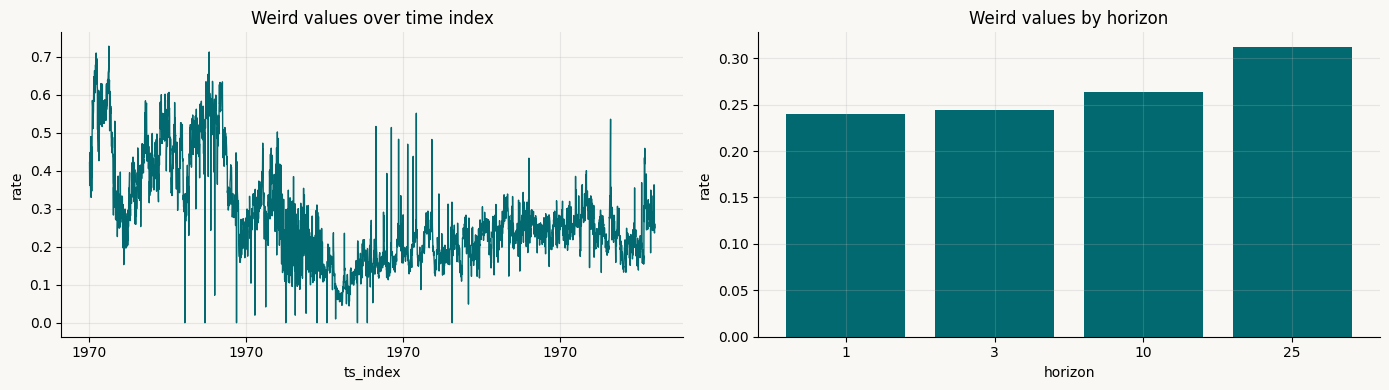

In [35]:
# flag rate over time and by horizon

if "df_flags" in globals():
    pass
elif "df_prep" in globals():
    df_flags = df_prep.copy()
else:
    print("Run the pipeline prep cell first (it creates row-level weird flags).")
    df_flags = None

if df_flags is not None:
    if TS_COL not in df_flags.columns or HORIZON_COL not in df_flags.columns:
        raise ValueError(f"{TS_COL} and/or {HORIZON_COL} not found in df_flags")

    if "row_flag_weird_any" not in df_flags.columns:
        weird_flag_cols = [
            c for c in df_flags.columns
            if c.endswith("__is_nan") or c.endswith("__is_outlier") or c.endswith("__is_spike")
        ]
        if len(weird_flag_cols) == 0:
            raise ValueError("No weird-flag columns found. Run pipeline prep cell first.")
        df_flags["row_flag_weird_any"] = (df_flags[weird_flag_cols].sum(axis=1) > 0).astype("int8")

    ts_summary = df_flags.groupby(TS_COL)["row_flag_weird_any"].mean().reset_index()
    h_summary = df_flags.groupby(HORIZON_COL)["row_flag_weird_any"].mean().reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(ts_summary[TS_COL], ts_summary["row_flag_weird_any"], color=TEAL, lw=1)
    axes[0].set_title("Weird values over time index")
    axes[0].set_xlabel(TS_COL)
    axes[0].set_ylabel("rate")

    axes[1].bar(h_summary[HORIZON_COL].astype(str), h_summary["row_flag_weird_any"], color=TEAL)
    axes[1].set_title("Weird values by horizon")
    axes[1].set_xlabel(HORIZON_COL)
    axes[1].set_ylabel("rate")

    plt.tight_layout()
    plt.show()

## 8.4 Yeo-Johnson Transformation

In [36]:
WINSOR_LO, WINSOR_HI = 0.01, 0.99

if len(num_features) == 0:
    result_df = pd.DataFrame(columns=["feature", "kurt_raw", "kurt_after_yj", "kurt_after_qt", "recommended", "yj_lambda"])
    print("No numeric features for transformation plan")
else:
    cand = skew_kurt.index.tolist()[:20] if "skew_kurt" in globals() and len(skew_kurt) > 0 else num_features[:20]
    results = []

    for col in cand:
        sraw = pd.to_numeric(df_eda[col], errors="coerce").dropna()
        if len(sraw) < 300:
            continue
        if len(sraw) > 150000:
            sraw = sraw.sample(150000, random_state=SEED)

        lo, hi = sraw.quantile(WINSOR_LO), sraw.quantile(WINSOR_HI)
        swins = sraw.clip(lo, hi)

        pt = PowerTransformer(method="yeo-johnson", standardize=True)
        syj = pd.Series(pt.fit_transform(swins.values.reshape(-1, 1)).ravel())

        qt = QuantileTransformer(output_distribution="normal", random_state=SEED)
        sqt = pd.Series(qt.fit_transform(swins.values.reshape(-1, 1)).ravel())

        rec = "quantile-normal" if syj.kurtosis() > 10 else "yeo-johnson"

        results.append({
            "feature": col,
            "skew_raw": round(sraw.skew(), 2),
            "kurt_raw": round(sraw.kurtosis(), 1),
            "kurt_after_yj": round(syj.kurtosis(), 1),
            "kurt_after_qt": round(sqt.kurtosis(), 1),
            "yj_lambda": round(float(pt.lambdas_[0]), 4),
            "recommended": rec,
        })

    result_df = pd.DataFrame(results)
    # in order to inspect values:
    result_df = result_df.sort_values("yj_lambda", ascending=False).reset_index(drop=True)
    result_df2 = result_df.sort_values("yj_lambda", ascending=True).reset_index(drop=True)

    still_bad = result_df[result_df["kurt_after_yj"] > 10]

    print(f"Features still extreme (kurtosis > 10) after Yeo-Johnson: {len(still_bad)}")
    if len(still_bad) > 0:
        print(still_bad[["feature", "kurt_raw", "kurt_after_yj", "kurt_after_qt", "recommended"]].to_string(index=False))

    print("\nTransformation plan (top 15):") # initially 30, but after checking, 15 is enough
    print(result_df.head(15)[["feature", "kurt_raw", "kurt_after_yj", "recommended", "yj_lambda"]].to_string(index=False))

    print("\nTransformation plan (top 15):")
    print(result_df2.head(15)[["feature", "kurt_raw", "kurt_after_yj", "recommended", "yj_lambda"]].to_string(index=False))

Features still extreme (kurtosis > 10) after Yeo-Johnson: 1
   feature  kurt_raw  kurt_after_yj  kurt_after_qt     recommended
feature_al     262.7           15.9            5.5 quantile-normal

Transformation plan (top 15):
   feature  kurt_raw  kurt_after_yj     recommended  yj_lambda
feature_by     340.6           -0.1     yeo-johnson    16.2870
feature_bz     266.5            0.6     yeo-johnson    10.9241
feature_ca     126.7            0.3     yeo-johnson     7.6065
feature_cc     222.2            0.7     yeo-johnson     6.6405
feature_cd     168.6            0.5     yeo-johnson     5.5094
feature_ce     231.0            4.2     yeo-johnson     2.1278
feature_al     262.7           15.9 quantile-normal     1.0017
feature_aw     177.4           -0.9     yeo-johnson     0.0846
feature_au     190.3           -0.8     yeo-johnson     0.0845
feature_bb     227.2           -1.1     yeo-johnson     0.0073
feature_ba     777.5           -1.2     yeo-johnson    -0.0233
feature_bc     270.

## 8.5 Getting ready for the models

In [37]:
final_cols = list(set(series_cols + [HORIZON_COL, TS_COL, "split", TARGET, WEIGHT] + model_features))
model_df = df_prep[final_cols].copy()

summary_by_split_h = (
    model_df.groupby(["split", HORIZON_COL])
    .agg(
        n_rows=(TARGET, "size"),
        target_mean=(TARGET, "mean"),
        target_std=(TARGET, "std"),
        time_min=(TS_COL, "min"),
        time_max=(TS_COL, "max"),
    )
    .reset_index()
    .sort_values(["split", HORIZON_COL])
)

feature_nan_after_prep = int(model_df[model_features].isna().sum().sum())
horizon_frames = {int(h): model_df[model_df[HORIZON_COL] == h].copy() for h in sorted(model_df[HORIZON_COL].dropna().unique())}

print(f"final_model_shape={model_df.shape}")
print(f"nan_entries_in_model_features={feature_nan_after_prep}")
print(f"n_horizon_frames={len(horizon_frames)}")
print(summary_by_split_h.to_string(index=False))

final_model_shape=(5337414, 45)
nan_entries_in_model_features=0
n_horizon_frames=4
split  horizon  n_rows  target_mean  target_std                      time_min                      time_max
train        1 1115052    -0.095153   12.044804 1970-01-01 00:00:00.000000001 1970-01-01 00:00:00.000002967
train        3 1108291    -0.302090   19.860269 1970-01-01 00:00:00.000000001 1970-01-01 00:00:00.000002967
train       10 1070690    -0.914223   34.627628 1970-01-01 00:00:00.000000001 1970-01-01 00:00:00.000002967
train       25  977024    -2.004484   54.875871 1970-01-01 00:00:00.000000001 1970-01-01 00:00:00.000002967
valid        1  279601    -0.033139   10.207818 1970-01-01 00:00:00.000002968 1970-01-01 00:00:00.000003601
valid        3  277525    -0.054009   17.223143 1970-01-01 00:00:00.000002968 1970-01-01 00:00:00.000003601
valid       10  266546    -0.220596   30.476963 1970-01-01 00:00:00.000002968 1970-01-01 00:00:00.000003601
valid       25  242685    -0.383104   43.568666 1970-

### 8.5.1 correlation heatmap of cleaned selected features

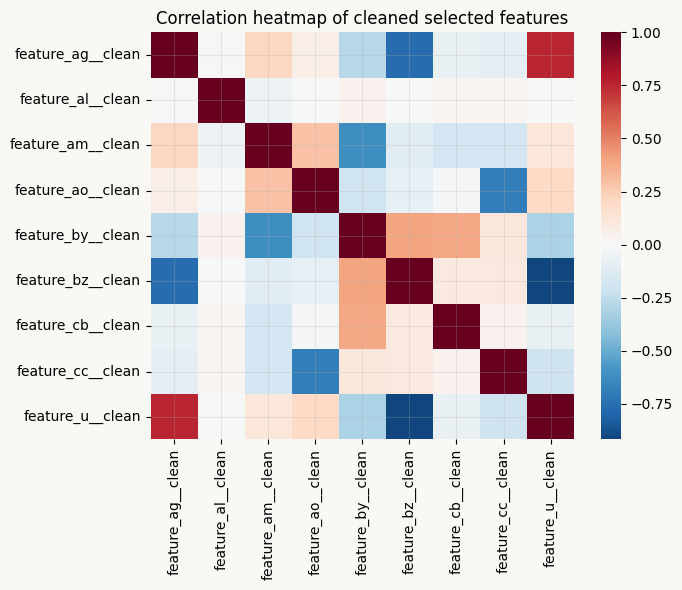

In [38]:

clean_cols = [f"{f}__clean" for f in selected_features if f"{f}__clean" in df_prep.columns]
if len(clean_cols) >= 2:
    corr_mat = df_prep[clean_cols].corr().fillna(0.0)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr_mat, cmap="RdBu_r", center=0, ax=ax)
    ax.set_title("Correlation heatmap of cleaned selected features")
    plt.tight_layout()
    plt.show()


## 8.6 Correlated features

In [79]:
CORR_CUT = 0.65 # subject to change
MAX_POOL = 80
TOP_GLOBAL = 16
TOP_PER_H = 12
SAMPLE_N = 50_000

if "ic_df" in globals() and len(ic_df) > 0 and "mean_abs_IC" in ic_df.columns:
    rank_global = ic_df["mean_abs_IC"].sort_values(ascending=False).index.tolist()
elif "feature_target_corr" in globals() and len(feature_target_corr) > 0:
    rank_global = feature_target_corr.sort_values("abs_corr", ascending=False)["feature"].tolist()
else:
    raise ValueError("Need ic_df or feature_target_corr to rank features.")

rank_global = [f for f in rank_global if f in df.columns]
if len(rank_global) == 0:
    raise ValueError("No ranked features available in df.")

sample_df = df[rank_global].dropna(how="all")
if len(sample_df) > SAMPLE_N:
    sample_df = sample_df.sample(SAMPLE_N, random_state=SEED)

corr_abs_global = sample_df.corr().abs().fillna(0.0)


In [80]:
def pick_decorrelated(ranked_features, corr_abs, top_k=12, corr_cut=0.85): # helper function
    picked = []
    for f in ranked_features:
        if f not in corr_abs.columns:
            continue
        if len(picked) == 0:
            picked.append(f)
            continue
        max_corr = corr_abs.loc[f, picked].max()
        if pd.isna(max_corr) or float(max_corr) < corr_cut:
            picked.append(f)
        if len(picked) >= top_k:
            break
    return picked


In [81]:
feature_sets_uncorr = {}

# global set
pool_global = rank_global[:MAX_POOL]
feature_sets_uncorr["set_global_uncorr"] = pick_decorrelated(
    pool_global, corr_abs_global, top_k=TOP_GLOBAL, corr_cut=CORR_CUT
)

# per-horizon sets
if "ic_df" in globals() and len(ic_df) > 0:
    ic_mat = ic_df.drop(columns=["mean_abs_IC"], errors="ignore")
    for h in ic_mat.columns:
        ranked_h = ic_mat[h].abs().sort_values(ascending=False).index.tolist()
        ranked_h = [f for f in ranked_h if f in df.columns][:MAX_POOL]
        feature_sets_uncorr[f"set_h{int(h)}_uncorr"] = pick_decorrelated(
            ranked_h, corr_abs_global, top_k=TOP_PER_H, corr_cut=CORR_CUT
        )

for k, v in feature_sets_uncorr.items():
    print(f"{k}: {len(v)} features")


set_global_uncorr: 16 features
set_h1_uncorr: 12 features
set_h3_uncorr: 12 features
set_h10_uncorr: 12 features
set_h25_uncorr: 12 features


In [82]:
rows = []
for name, feats in feature_sets_uncorr.items():
    feats = [f for f in feats if f in corr_abs_global.columns]

    if len(feats) <= 1:
        max_abs_corr = np.nan
    else:
        cm = corr_abs_global.loc[feats, feats].to_numpy(copy=True)  # writable copy
        np.fill_diagonal(cm, 0.0)
        max_abs_corr = float(np.nanmax(cm))

    rows.append({
        "set_name": name,
        "n_features": len(feats),
        "max_abs_corr_in_set": max_abs_corr,
        "corr_cut": CORR_CUT
    })

uncorr_summary = pd.DataFrame(rows).sort_values("set_name").reset_index(drop=True)
print(uncorr_summary.to_string(index=False))


         set_name  n_features  max_abs_corr_in_set  corr_cut
set_global_uncorr          16              0.60819      0.65
   set_h10_uncorr          12              0.58114      0.65
    set_h1_uncorr          12              0.58114      0.65
   set_h25_uncorr          12              0.58114      0.65
    set_h3_uncorr          12              0.58114      0.65


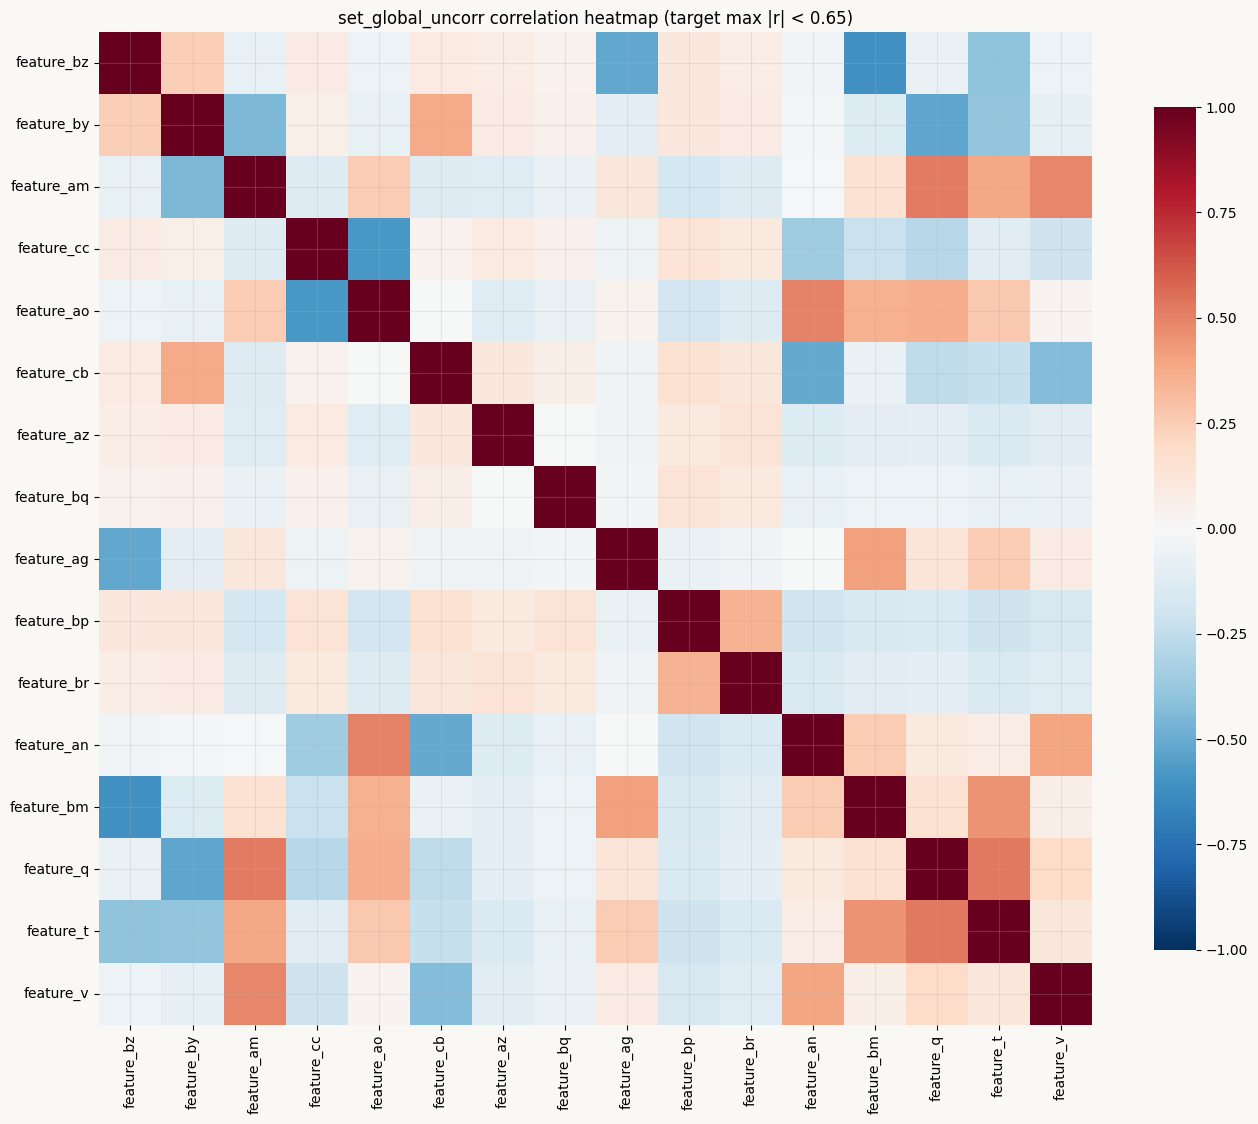

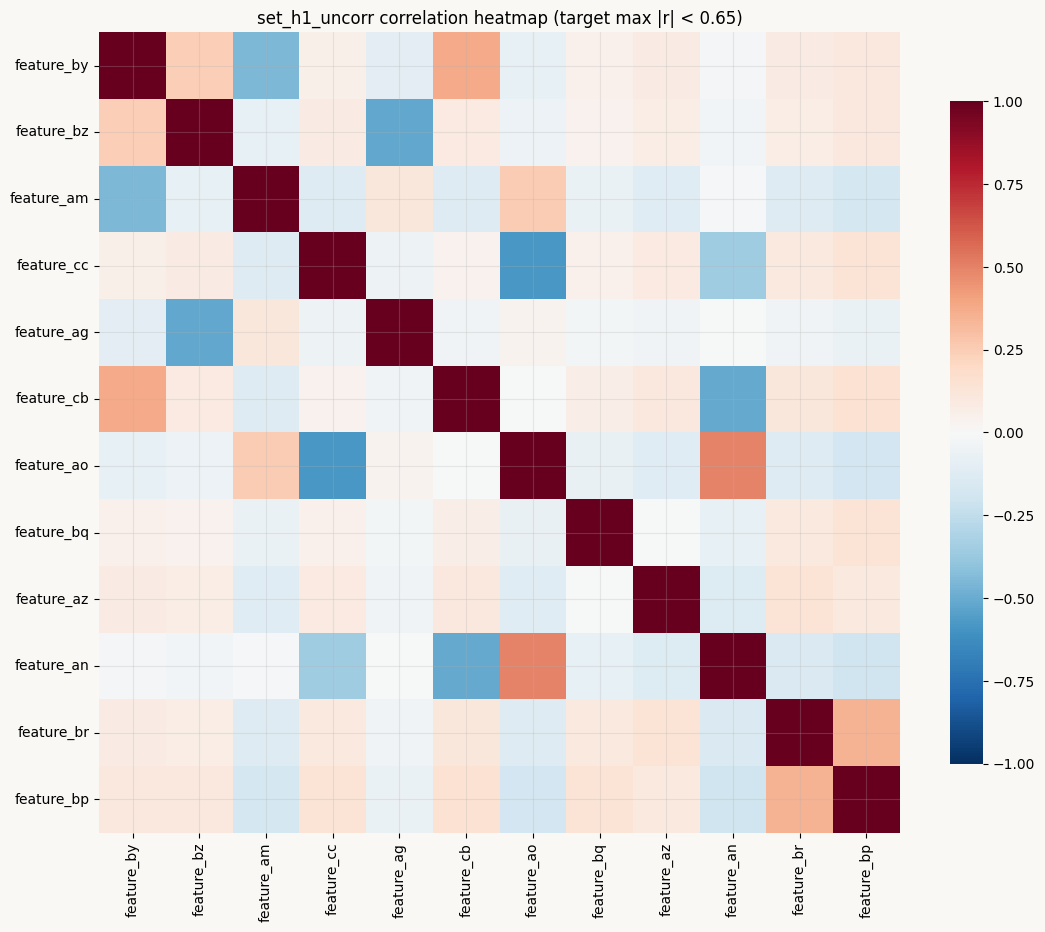

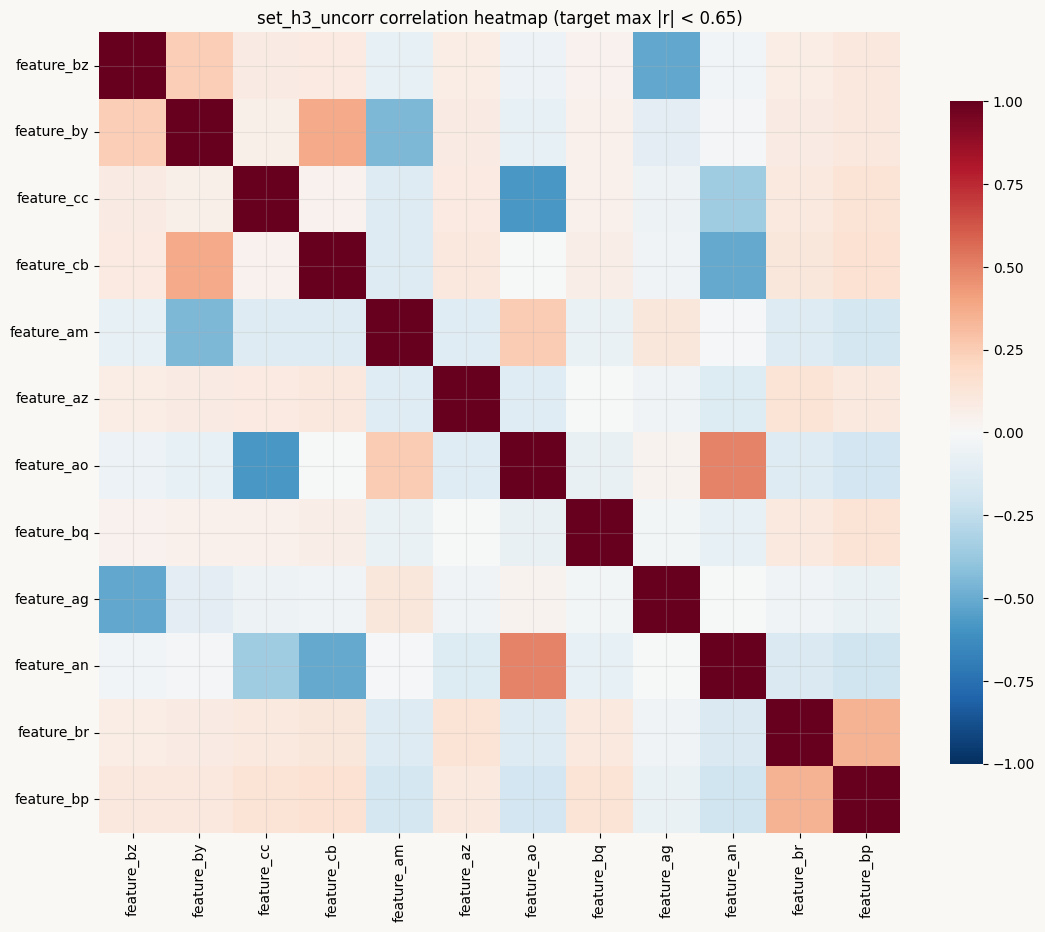

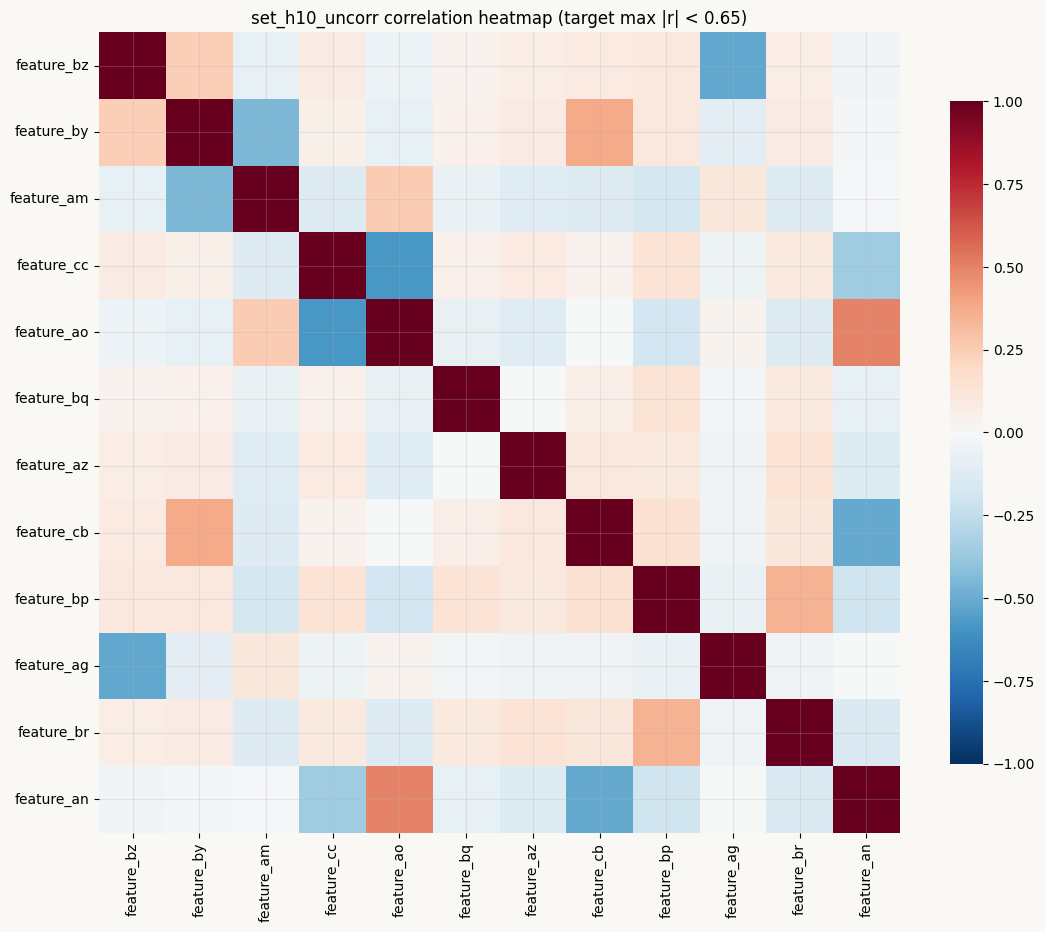

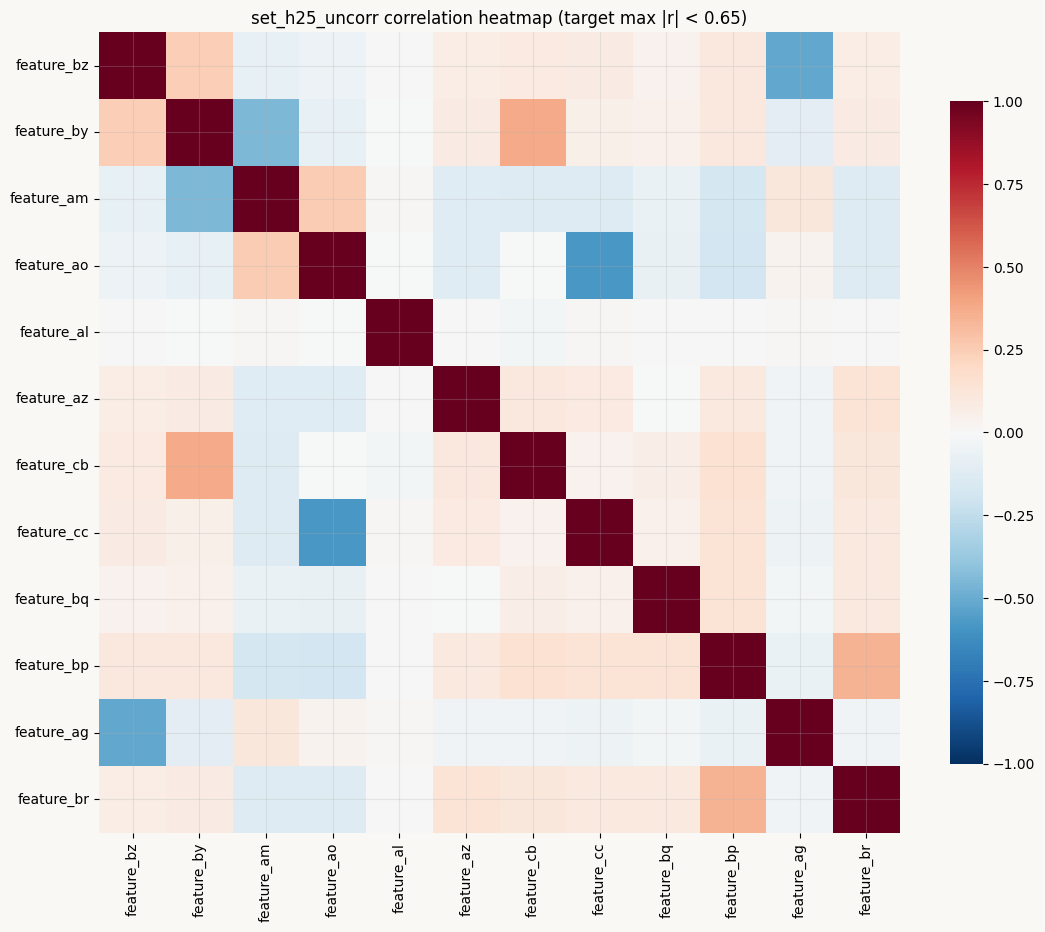

In [83]:
for name, feats in feature_sets_uncorr.items():
    if len(feats) < 2:
        print(f"{name}: skipped heatmap (fewer than 2 features)")
        continue

    cm = sample_df[feats].corr().fillna(0.0)

    fig, ax = plt.subplots(figsize=(0.6 * len(feats) + 4, 0.6 * len(feats) + 3))
    sns.heatmap(
        cm,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        ax=ax,
        cbar_kws={"shrink": 0.7},
    )
    ax.set_title(f"{name} correlation heatmap (target max |r| < {CORR_CUT})")
    plt.tight_layout()
    plt.show()


# 9 Save potential feature sets

In [44]:
from pathlib import Path

out_root = Path("output/uncorr")
out_dir = out_root / "feature_set_exports_m1_simple"
out_dir.mkdir(parents=True, exist_ok=True)

feature_sets = {}

# previously created uncorrelated sets
if "feature_sets_uncorr" in globals() and isinstance(feature_sets_uncorr, dict) and len(feature_sets_uncorr) > 0:
    for k, v in feature_sets_uncorr.items():
        if isinstance(v, (list, tuple, np.ndarray, pd.Index)):
            feature_sets[k] = [f for f in list(v) if f in df.columns]

# Fallback: if no uncorr sets found
if len(feature_sets) == 0:
    if "ic_df" in globals() and len(ic_df) > 0:
        rank = ic_df.sort_values("mean_abs_IC", ascending=False).index.tolist()
        feature_sets["set_global_core"] = rank[:12]
        feature_sets["set_global_support"] = rank[:24]
    elif "feature_target_corr" in globals() and len(feature_target_corr) > 0:
        rank = feature_target_corr["feature"].tolist()
        feature_sets["set_global_core"] = rank[:12]
        feature_sets["set_global_support"] = rank[:24]

    if "ic_df" in globals() and len(ic_df) > 0:
        ic_mat = ic_df.drop(columns=["mean_abs_IC"], errors="ignore")
        for h in ic_mat.columns:
            s = ic_mat[h].abs().sort_values(ascending=False)
            feature_sets[f"set_h{int(h)}_core"] = s.head(8).index.tolist()
            feature_sets[f"set_h{int(h)}_support"] = s.head(16).index.tolist()

# Clean empty sets
feature_sets = {k: [f for f in v if f in df.columns] for k, v in feature_sets.items() if isinstance(v, list) and len(v) > 0}

membership_rows = [{"set_name": k, "feature": f} for k, feats in feature_sets.items() for f in feats]
feature_set_membership = pd.DataFrame(membership_rows)
feature_set_membership.to_csv(out_root / "feature_set_membership_m1_simple.csv", index=False)

key_cols = [c for c in ["id", "code", "sub_code", "sub_category", HORIZON_COL, TS_COL] if c in df.columns]
export_rows = []

for set_name, feats in feature_sets.items():
    if len(feats) == 0:
        continue

    part = df
    if set_name.startswith("set_h") and HORIZON_COL in part.columns:
        try:
            h_val = int(set_name.split("_")[1][1:])
            part = part[part[HORIZON_COL] == h_val]
        except Exception:
            pass

    cols = [c for c in key_cols + feats if c in part.columns]
    out_path = out_dir / f"{set_name}.parquet"

    if len(key_cols) > 0 and all(c in part.columns for c in key_cols):
        part[cols].sort_values(key_cols).to_parquet(out_path, index=False)
    else:
        part[cols].to_parquet(out_path, index=False)

    export_rows.append({
        "set_name": set_name,
        "n_rows": int(len(part)),
        "n_features": int(len(feats)),
        "file": str(out_path),
    })

export_summary = pd.DataFrame(export_rows).sort_values("set_name").reset_index(drop=True)
export_summary.to_csv(out_root / "feature_set_export_summary_m1_simple.csv", index=False)

print(export_summary.to_string(index=False) if len(export_summary) > 0 else "No feature sets exported")
print(f"Saved outputs in: {out_root}")


         set_name  n_rows  n_features                                                                  file
set_global_uncorr 5337414          16 output/uncorr/feature_set_exports_m1_simple/set_global_uncorr.parquet
   set_h10_uncorr 1337236          12    output/uncorr/feature_set_exports_m1_simple/set_h10_uncorr.parquet
    set_h1_uncorr 1394653          12     output/uncorr/feature_set_exports_m1_simple/set_h1_uncorr.parquet
   set_h25_uncorr 1219709          12    output/uncorr/feature_set_exports_m1_simple/set_h25_uncorr.parquet
    set_h3_uncorr 1385816          12     output/uncorr/feature_set_exports_m1_simple/set_h3_uncorr.parquet
Saved outputs in: output/uncorr


# 10. Checking the number of entries per codes, subcodes and sub category

In [45]:
code_counts = (
    df.groupby("code")
      .size()
      .reset_index(name="n_rows")
      .sort_values("n_rows", ascending=False)
      .reset_index(drop=True)
)

display(code_counts)

,code,n_rows
0,OSJL3A7Y,564790
1,6LB028J8,484082
2,K7Y1TTAH,324479
3,VFWIFJPS,318517
4,W2MW3G2L,305116
5,1HEMHZK2,293024
6,660DZME0,264071
7,4KUR2ZOZ,263685
8,SJZP0OVU,237283
9,84J8BJFZ,234375


In [46]:
subcode_counts = (
    df.groupby("sub_code")
      .size()
      .reset_index(name="n_rows")
      .sort_values("n_rows", ascending=False)
      .reset_index(drop=True)
)

display(subcode_counts)

,sub_code,n_rows
0,69SD4Y3A,69521
1,OYJGNSQK,69390
2,TI04KMOC,68844
3,XT8JWYHT,68515
4,PCXKOBIH,68383
...,...,...
175,R8ECWR4M,1724
176,ODPORHON,834
177,CXK160RR,140
178,SNJ5FTC0,123


In [47]:
subcategory_counts = (
    df.groupby("sub_category")
      .size()
      .reset_index(name="n_rows")
      .sort_values("n_rows", ascending=False)
      .reset_index(drop=True)
)

display(subcategory_counts)

,sub_category,n_rows
0,PZ9S1Z4V,1074239
1,DPPUO5X2,1072705
2,NQ58FVQM,1067164
3,PHHHVYZI,1067164
4,V8BKY1IV,1056142


## 10.1 Checking their percenatges, only for codes and subcodes

In [48]:
code_counts = (
    df.groupby("code")
    .size()
    .reset_index(name="n_entries")
)

code_counts["n_entries"] = 100 * code_counts["n_entries"] / code_counts["n_entries"].sum()

code_counts = (
    code_counts
    .sort_values("n_entries", ascending=False)
    .reset_index(drop=True)
)

display(code_counts.round(2))


,code,n_entries
0,OSJL3A7Y,10.58
1,6LB028J8,9.07
2,K7Y1TTAH,6.08
3,VFWIFJPS,5.97
4,W2MW3G2L,5.72
5,1HEMHZK2,5.49
6,660DZME0,4.95
7,4KUR2ZOZ,4.94
8,SJZP0OVU,4.45
9,84J8BJFZ,4.39


In [49]:
subcode_counts = (
    df.groupby("sub_code")
    .size()
    .reset_index(name="n_entries")
)

subcode_counts["n_entries"] = 100 * subcode_counts["n_entries"] / subcode_counts["n_entries"].sum()

subcode_counts = (
    subcode_counts
    .sort_values("n_entries", ascending=False)
    .reset_index(drop=True)
)

display(subcode_counts.round(2))


,sub_code,n_entries
0,69SD4Y3A,1.30
1,OYJGNSQK,1.30
2,TI04KMOC,1.29
3,XT8JWYHT,1.28
4,PCXKOBIH,1.28
...,...,...
175,R8ECWR4M,0.03
176,ODPORHON,0.02
177,CXK160RR,0.00
178,SNJ5FTC0,0.00


### 10.1.1 The percentage of entries group by code and subcodes

In [50]:
subcode_counts = (
    df.groupby(["code", "sub_code"])
    .size()
    .reset_index(name="n_entries")
)

subcode_counts["n_entries"] = (
    100 * subcode_counts["n_entries"]
    / subcode_counts.groupby("code")["n_entries"].transform("sum")
)

subcode_counts = (
    subcode_counts
    .sort_values(["code", "n_entries"], ascending=[True, False])
    .reset_index(drop=True)
)

display(subcode_counts.round(2))


,code,sub_code,n_entries
0,10BAVIDU,2FDNH5AZ,2.97
1,10BAVIDU,7KROPSTS,2.97
2,10BAVIDU,XQ1K5P1N,2.96
3,10BAVIDU,AM753YDV,2.95
4,10BAVIDU,5N1DVPNK,2.95
...,...,...,...
1851,X9BZ68VQ,6HC1CGUV,0.65
1852,X9BZ68VQ,4K5656C0,0.34
1853,X9BZ68VQ,495MGHFJ,0.29
1854,X9BZ68VQ,R8ECWR4M,0.25


# 11. Data exploration 

## 11.1 Seasonal Decompose 

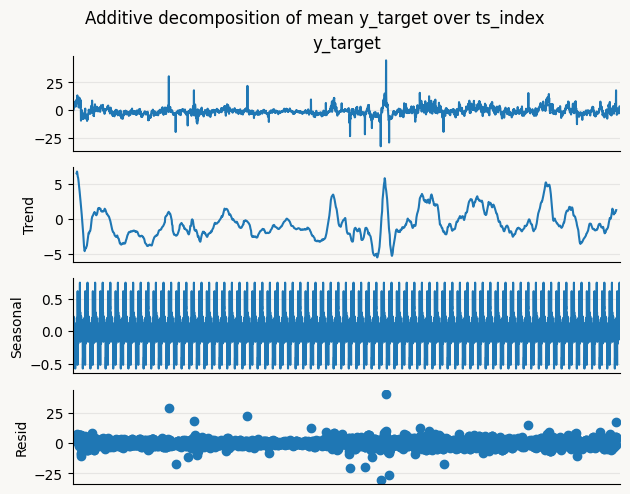

In [51]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = df.groupby("ts_index")["y_target"].mean()

result = seasonal_decompose(series, model="additive", period=50)

result.plot()
plt.suptitle("Additive decomposition of mean y_target over ts_index", y=1.02)
plt.show()


## 11.2 Mean and median over ts 

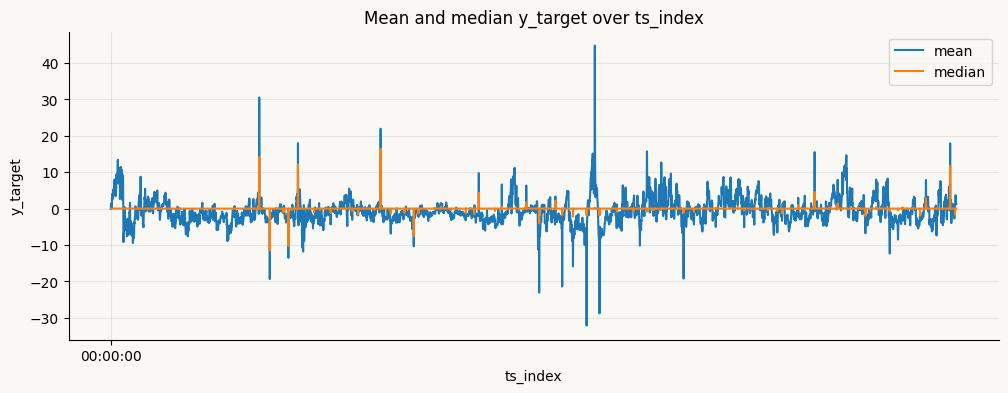

In [52]:
mean_by_time = df.groupby("ts_index")["y_target"].mean()
median_by_time = df.groupby("ts_index")["y_target"].median()

plt.figure(figsize=(12,4))
plt.plot(mean_by_time.index, mean_by_time.values, label="mean")
plt.plot(median_by_time.index, median_by_time.values, label="median")
plt.title("Mean and median y_target over ts_index")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.legend()
plt.show()

## 11.3 Outlier per ts (y_target)

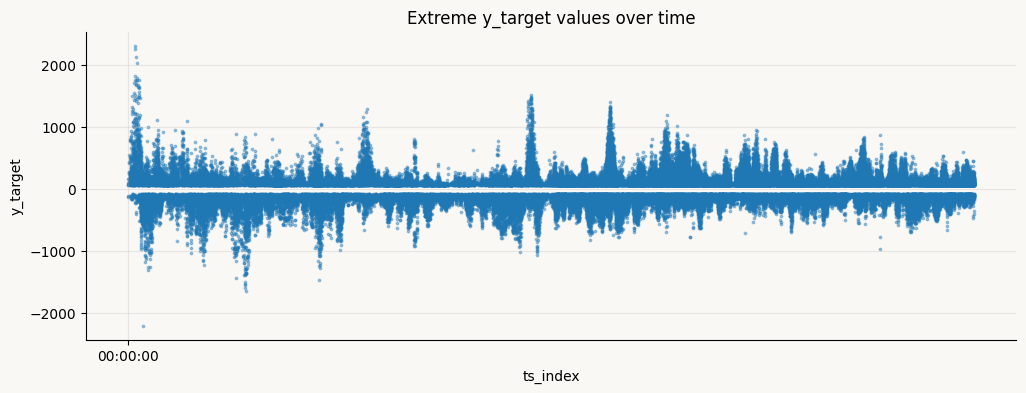

In [53]:
extreme_df = df[
    (df["y_target"] < df["y_target"].quantile(0.01)) |
    (df["y_target"] > df["y_target"].quantile(0.99))
]

plt.figure(figsize=(12, 4))
plt.scatter(extreme_df["ts_index"], extreme_df["y_target"], s=3, alpha=0.4)
plt.title("Extreme y_target values over time")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()

## 11.3.1 Outlier per ts (other features)

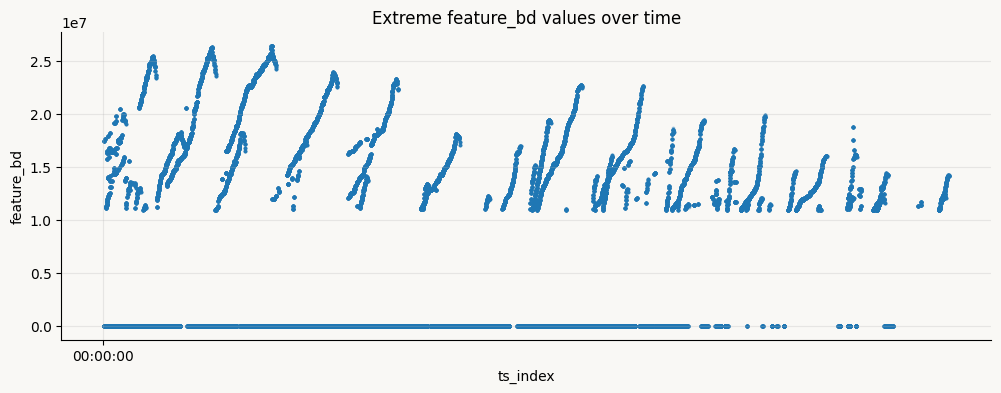

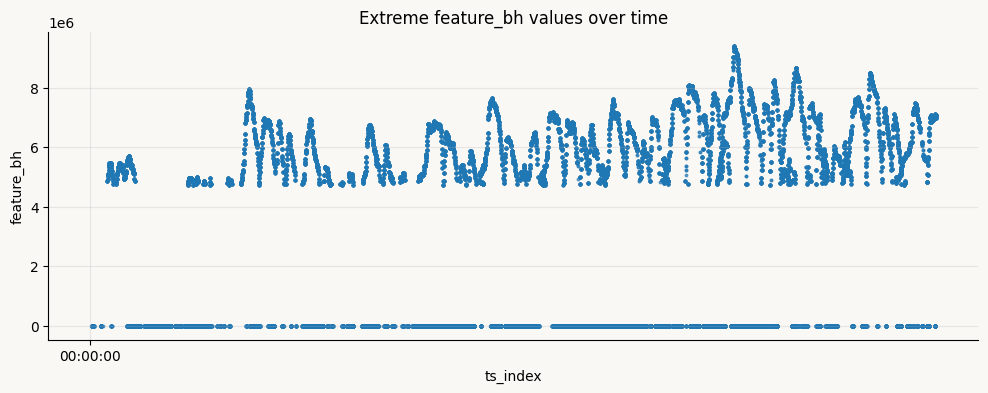

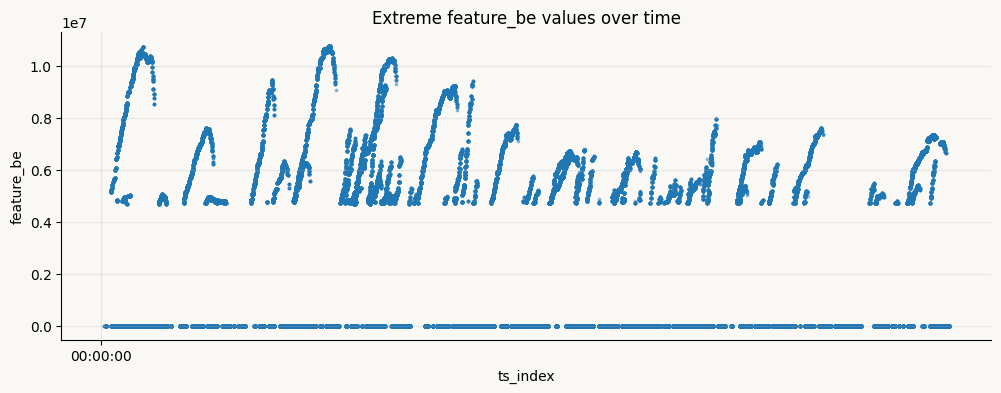

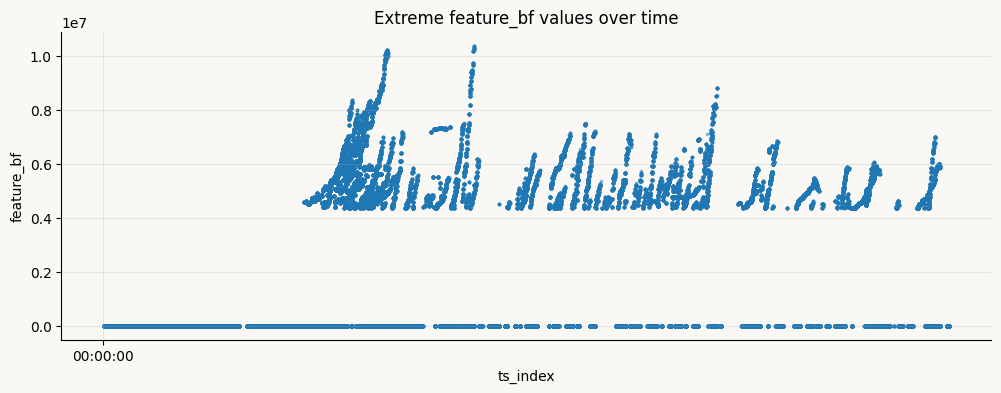

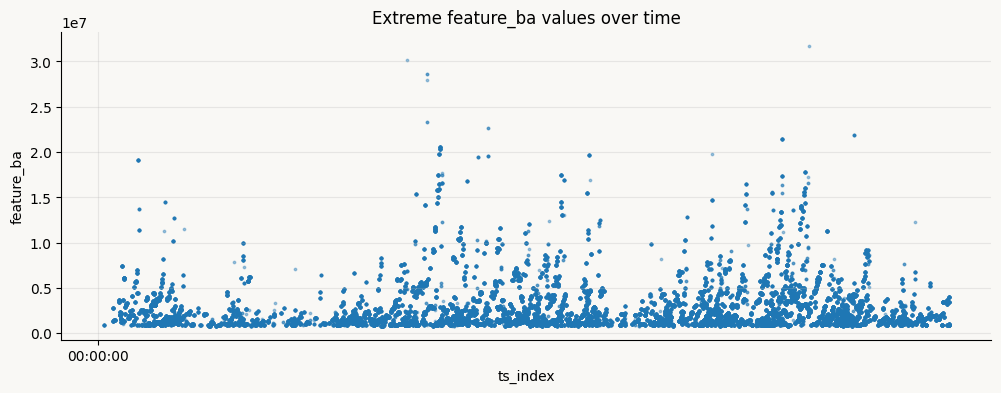

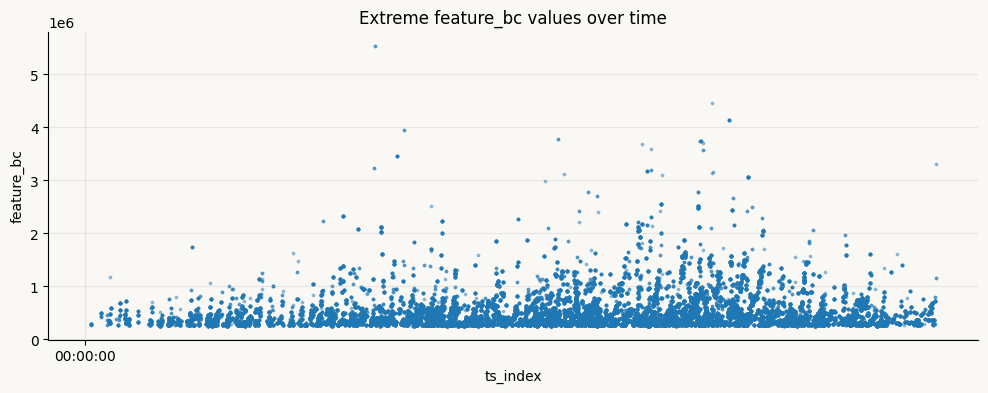

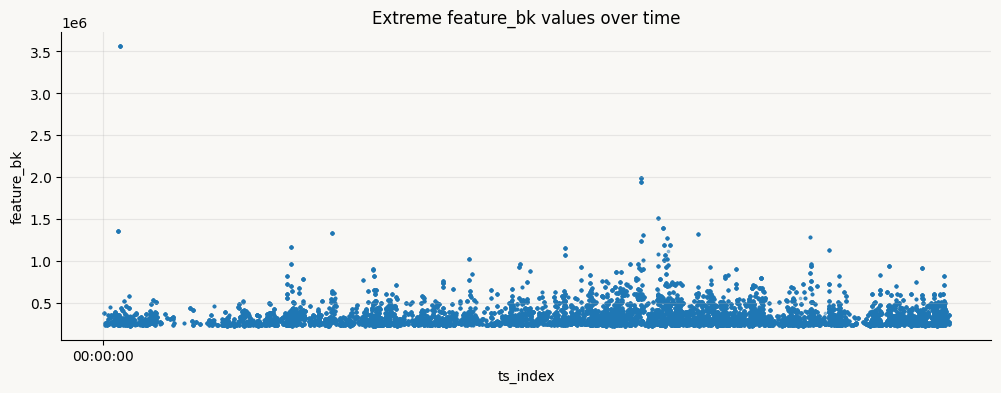

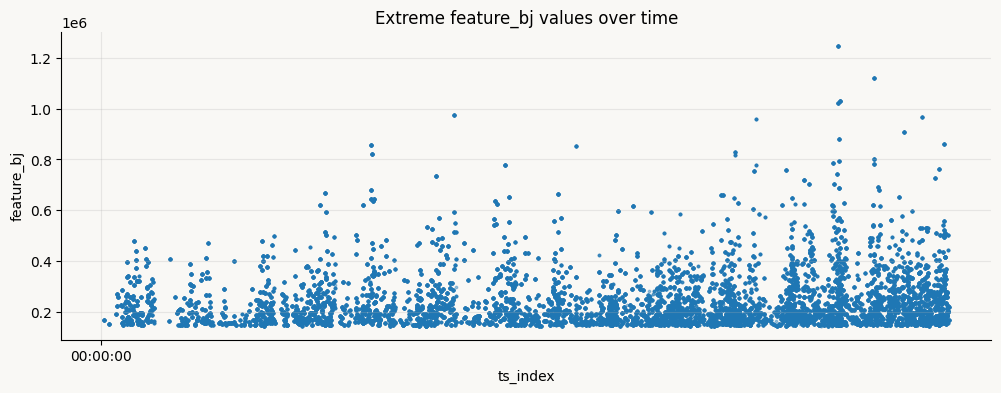

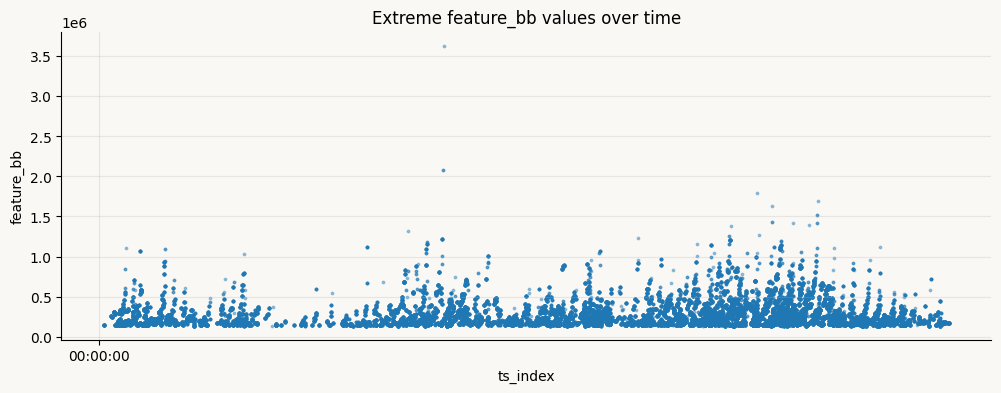

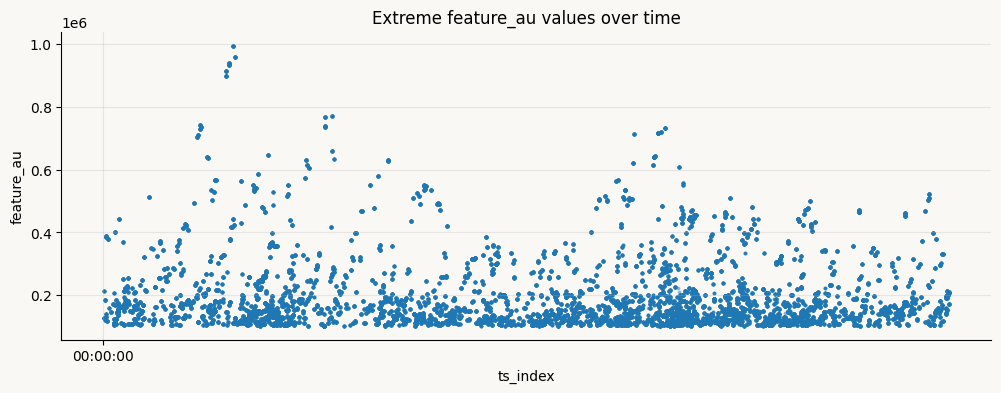

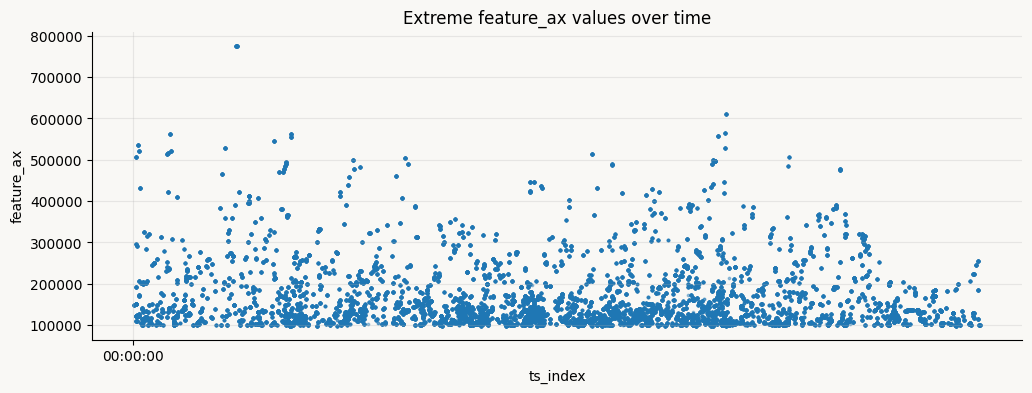

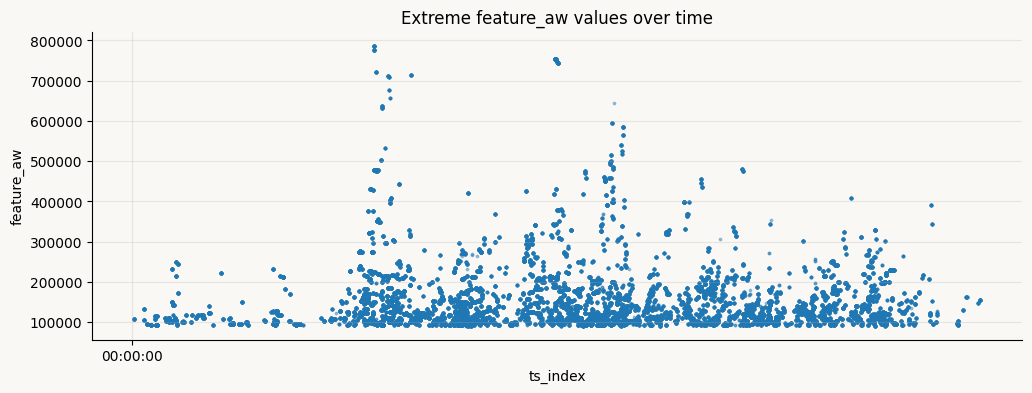

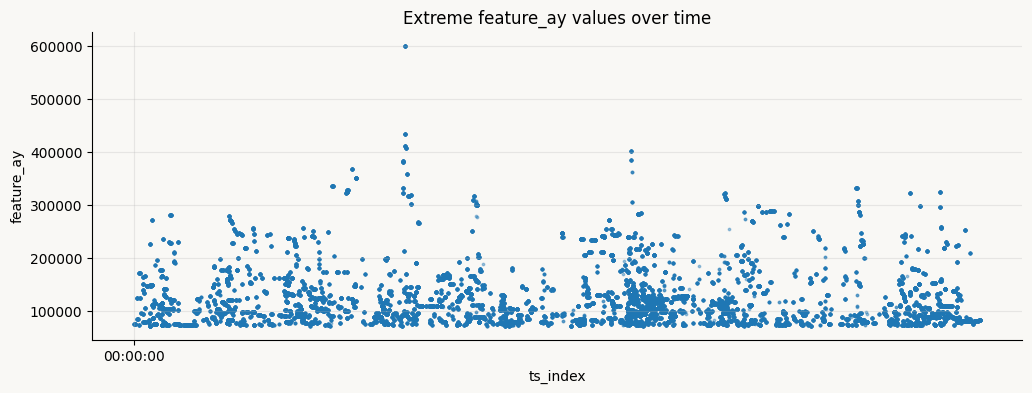

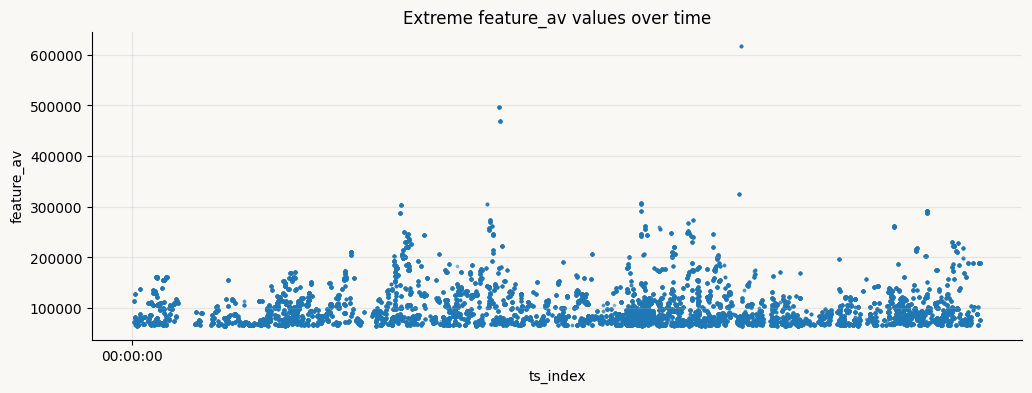

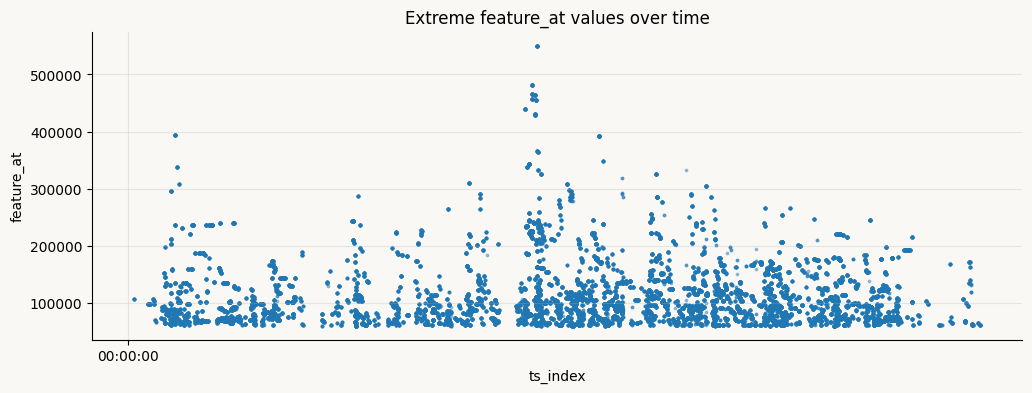

In [54]:
feature_cols = [c for c in df.columns if c.startswith("feature_")]

rows = []
for col in feature_cols:
    s = df[col].dropna()
    if len(s) == 0:
        continue

    low = s.quantile(0.01)
    high = s.quantile(0.99)

    rows.append({
        "feature": col,
        "max_score": max(abs(low), abs(high))
    })

outlier_df = pd.DataFrame(rows)

cols_to_plot = outlier_df.sort_values("max_score", ascending=False)["feature"].head(15).tolist()
feature_time_df = df[["ts_index"] + cols_to_plot].copy()

for col in cols_to_plot:
    low = feature_time_df[col].quantile(0.01)
    high = feature_time_df[col].quantile(0.99)

    extreme_df = feature_time_df[
        (feature_time_df[col] < low) |
        (feature_time_df[col] > high)
    ]

    plt.figure(figsize=(12, 4))
    plt.scatter(extreme_df["ts_index"], extreme_df[col], s=3, alpha=0.4)
    plt.title(f"Extreme {col} values over time")
    plt.xlabel("ts_index")
    plt.ylabel(col)
    plt.show()


# Build an ARIMA

code            2RBMUWP1
sub_code        DYJUJX3J
sub_category    PZ9S1Z4V
horizon                1
n_rows               213
Name: 0, dtype: object
MAE: 1.5652
RMSE: 2.6187


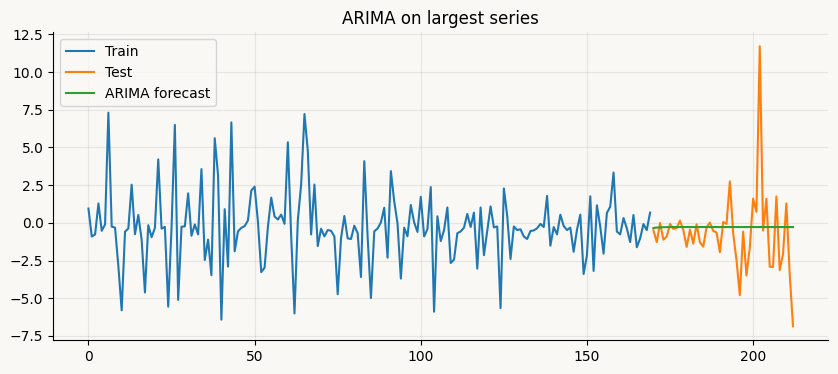

In [55]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
series_counts = (
    df.groupby(["code", "sub_code", "sub_category", "horizon"])
    .size()
    .reset_index(name="n_rows")
    .sort_values("n_rows", ascending=False)
    .reset_index(drop=True)
)

best = series_counts.iloc[0]
print(best)

one_series = df[
    (df["code"] == best["code"]) &
    (df["sub_code"] == best["sub_code"]) &
    (df["sub_category"] == best["sub_category"]) &
    (df["horizon"] == best["horizon"])
].sort_values("ts_index").copy()

y = one_series["y_target"].dropna().reset_index(drop=True)

split = int(len(y) * 0.8)
train = y.iloc[:split]
test = y.iloc[split:]

model = ARIMA(train, order=(1,0,1))
res = model.fit()

pred = res.forecast(steps=len(test))

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, pred, label="ARIMA forecast")
plt.legend()
plt.title("ARIMA on largest series")
plt.show()


## 12.1 Get its residuals and do ACF on them

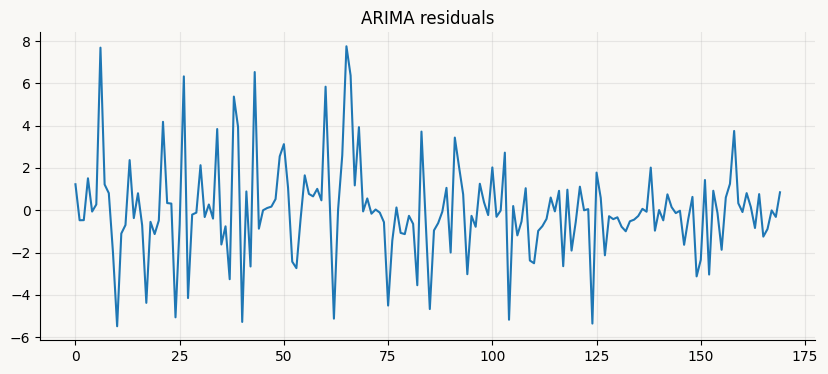

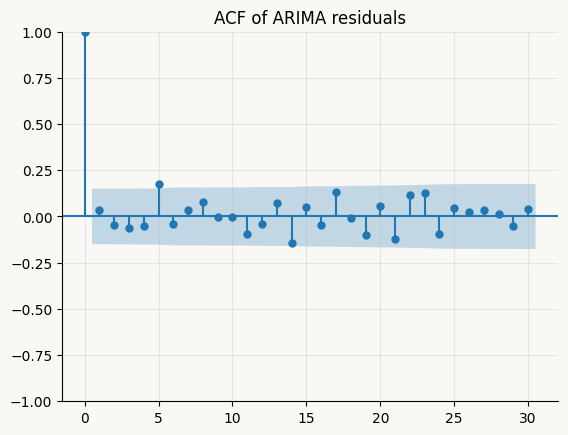

ARCH test p-value: 0.5005024488642374


In [56]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch


residuals = pd.Series(res.resid).dropna().reset_index(drop=True)

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("ARIMA residuals")
plt.show()

plot_acf(residuals, lags=30)
plt.title("ACF of ARIMA residuals")
plt.show()

arch_test = het_arch(residuals)
print("ARCH test p-value:", arch_test[1])


# 13. Arch models

## 13.1 Garch

In [57]:
from arch import arch_model

garch_model = arch_model(residuals, mean="Zero", vol="GARCH", p=1, q=1)
garch_res = garch_model.fit(disp="off")

print(garch_res.summary())


                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.006
Vol Model:                      GARCH   Log-Likelihood:               -372.731
Distribution:                  Normal   AIC:                           751.463
Method:            Maximum Likelihood   BIC:                           760.870
                                        No. Observations:                  170
Date:                Wed, Apr 22 2026   Df Residuals:                      170
Time:                        11:25:45   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      5.2159e-08  6.874e-02  7.588e-07      1.000 

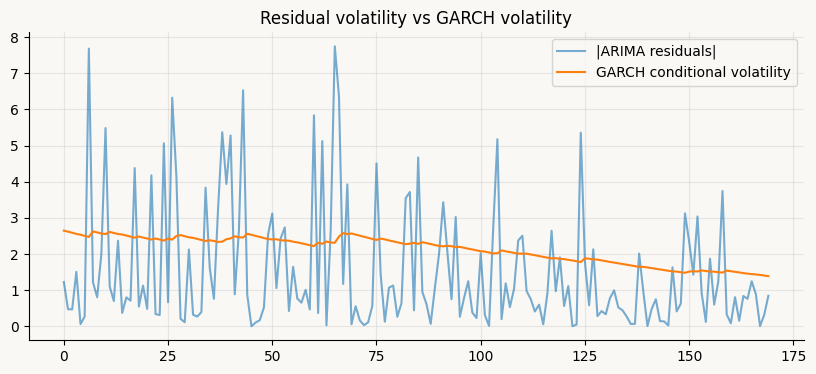

In [58]:
cond_vol = pd.Series(garch_res.conditional_volatility).reset_index(drop=True)

plt.figure(figsize=(10,4))
plt.plot(residuals.abs(), label="|ARIMA residuals|", alpha=0.6)
plt.plot(cond_vol, label="GARCH conditional volatility")
plt.title("Residual volatility vs GARCH volatility")
plt.legend()
plt.show()


In [59]:
alpha = garch_res.params["alpha[1]"]
beta = garch_res.params["beta[1]"]

print("alpha:", round(alpha, 4))
print("beta:", round(beta, 4))
print("persistence:", round(alpha + beta, 4))


alpha: 0.0157
beta: 0.9759
persistence: 0.9916


## 13.2 Figarch and Harch

In [60]:
import statsmodels.api as sm


residuals = pd.Series(res.resid).dropna().reset_index(drop=True)
realized_vol = residuals.abs()

resid_scaled = residuals * 100

#Figarch
try:
    figarch_model = arch_model(resid_scaled, mean="Zero", vol="FIGARCH", p=1, q=1)
    figarch_res = figarch_model.fit(disp="off")
    figarch_vol = pd.Series(figarch_res.conditional_volatility).reset_index(drop=True) / 100

    print("FIGARCH summary")
    print(figarch_res.summary())
except Exception as e:
    figarch_res = None
    figarch_vol = None
    print("FIGARCH failed:", e)

#Harch
sq = residuals**2

df_harch = pd.DataFrame({
    "y": sq,
    "lag1": sq.shift(1),
    "avg5": sq.rolling(5).mean().shift(1),
    "avg10": sq.rolling(10).mean().shift(1),
    "avg20": sq.rolling(20).mean().shift(1)
}).dropna()

X = sm.add_constant(df_harch[["lag1", "avg5", "avg10", "avg20"]])
y_h = df_harch["y"]

harch_res = sm.OLS(y_h, X).fit()
harch_vol = pd.Series(np.sqrt(harch_res.predict(X))).reset_index(drop=True)

print("\nHARCH summary")
print(harch_res.summary())


FIGARCH summary
                      Zero Mean - FIGARCH Model Results                       
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.006
Vol Model:                    FIGARCH   Log-Likelihood:               -1159.18
Distribution:                  Normal   AIC:                           2326.36
Method:            Maximum Likelihood   BIC:                           2338.90
                                        No. Observations:                  170
Date:                Wed, Apr 22 2026   Df Residuals:                      170
Time:                        11:25:46   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega        744.9077  2.282e+04  3.264

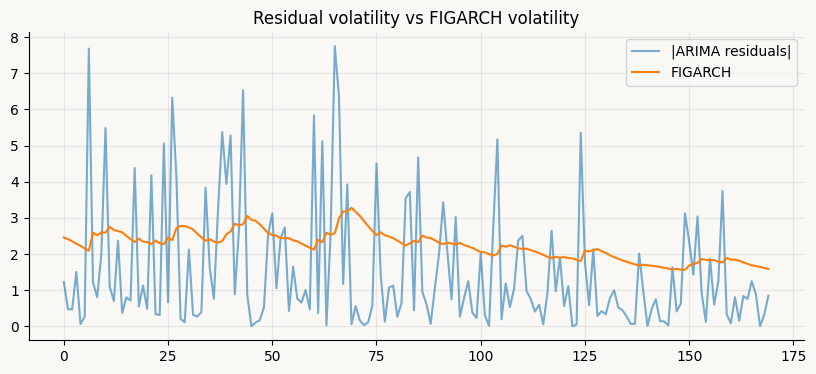

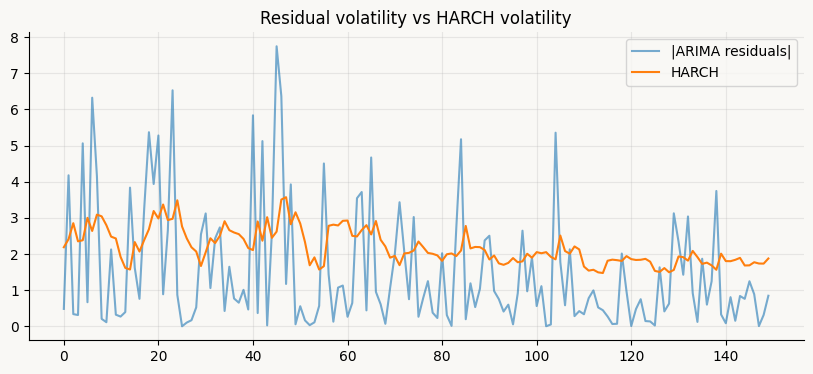

In [61]:
if figarch_vol is not None:
    min_len = min(len(realized_vol), len(figarch_vol))

    plt.figure(figsize=(10, 4))
    plt.plot(realized_vol.iloc[-min_len:].reset_index(drop=True), label="|ARIMA residuals|", alpha=0.6)
    plt.plot(figarch_vol.iloc[-min_len:].reset_index(drop=True), label="FIGARCH")
    plt.title("Residual volatility vs FIGARCH volatility")
    plt.legend()
    plt.show()

real_h = realized_vol.iloc[-len(harch_vol):].reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.plot(real_h, label="|ARIMA residuals|", alpha=0.6)
plt.plot(harch_vol, label="HARCH")
plt.title("Residual volatility vs HARCH volatility")
plt.legend()
plt.show()


## 13.3 Thier RMSE

In [62]:
rows = []

if "garch_vol" in globals():
    min_len = min(len(realized_vol), len(garch_vol))
    rmse_garch = np.sqrt(np.mean(
        (garch_vol.iloc[-min_len:].reset_index(drop=True) -
         realized_vol.iloc[-min_len:].reset_index(drop=True))**2
    ))
    rows.append({"model": "GARCH", "RMSE": rmse_garch})

if figarch_vol is not None:
    min_len = min(len(realized_vol), len(figarch_vol))
    rmse_figarch = np.sqrt(np.mean(
        (figarch_vol.iloc[-min_len:].reset_index(drop=True) -
         realized_vol.iloc[-min_len:].reset_index(drop=True))**2
    ))
    rows.append({"model": "FIGARCH", "RMSE": rmse_figarch})

rmse_harch = np.sqrt(np.mean((harch_vol - real_h)**2))
rows.append({"model": "HARCH", "RMSE": rmse_harch})

comparison = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
display(comparison.round(4))


,model,RMSE
0,HARCH,1.7812
1,FIGARCH,1.8389


In [63]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import PowerTransformer, QuantileTransformer, StandardScaler

meta_cols = [c for c in [TARGET, WEIGHT, HORIZON_COL, TS_COL, "split", "id", "code", "sub_code", "sub_category"] if c in df.columns]

if "selected_features" not in globals() or len(selected_features) == 0:
    raise ValueError("selected_features is missing.")

selected_features = [f for f in selected_features if f in df.columns]
if len(selected_features) == 0:
    raise ValueError("No selected features found in df.")

train_full = df.copy()
test_full = df_test.copy()

if "split" in train_full.columns:
    train_fit = train_full[train_full["split"] == "train"].copy()
else:
    train_fit = train_full.copy()

fit_info = {}
use_scaling = True   # set False if your final model is tree-based

for f in selected_features:
    fit_info[f] = {}

    qtab = (
        train_fit[[HORIZON_COL, f]]
        .dropna()
        .groupby(HORIZON_COL)[f]
        .quantile([0.01, 0.99])
        .unstack()
        .rename(columns={0.01: "q01", 0.99: "q99"})
    )

    medtab = (
        train_fit[[HORIZON_COL, f]]
        .groupby(HORIZON_COL)[f]
        .median()
        .rename("median")
    )

    global_med = train_fit[f].median()

    fit_info[f]["qtab"] = qtab
    fit_info[f]["medtab"] = medtab
    fit_info[f]["global_med"] = global_med

    raw_train = pd.to_numeric(train_fit[f], errors="coerce")
    h_train = train_fit[HORIZON_COL]

    q01_train = h_train.map(qtab["q01"]) if "q01" in qtab.columns else pd.Series(np.nan, index=train_fit.index)
    q99_train = h_train.map(qtab["q99"]) if "q99" in qtab.columns else pd.Series(np.nan, index=train_fit.index)

    q01_train = q01_train.fillna(raw_train.quantile(0.01))
    q99_train = q99_train.fillna(raw_train.quantile(0.99))

    wins_train = raw_train.clip(lower=q01_train, upper=q99_train)

    med_train = h_train.map(medtab).fillna(global_med)
    imp_train = wins_train.fillna(med_train).fillna(0)

    yj = PowerTransformer(method="yeo-johnson", standardize=True)
    yj_train = yj.fit_transform(imp_train.to_numpy().reshape(-1, 1)).ravel()

    kurt_after_yj = pd.Series(yj_train).kurtosis()

    if kurt_after_yj > 10:
        qt = QuantileTransformer(output_distribution="normal", n_quantiles=min(1000, len(imp_train)), random_state=42)
        qt_train = qt.fit_transform(imp_train.to_numpy().reshape(-1, 1)).ravel()
        fit_info[f]["transform_type"] = "quantile"
        fit_info[f]["transformer"] = qt
        transformed_train = qt_train
    else:
        fit_info[f]["transform_type"] = "yeo-johnson"
        fit_info[f]["transformer"] = yj
        transformed_train = yj_train

    d_train = pd.Series(imp_train).groupby(train_fit[HORIZON_COL]).diff().abs()
    spike_thr = d_train.groupby(train_fit[HORIZON_COL]).quantile(0.995)
    global_spike_thr = d_train.quantile(0.995)

    fit_info[f]["spike_thr"] = spike_thr
    fit_info[f]["global_spike_thr"] = global_spike_thr

    if use_scaling:
        scaler = StandardScaler()
        scaler.fit(np.asarray(transformed_train).reshape(-1, 1))
        fit_info[f]["scaler"] = scaler
    else:
        fit_info[f]["scaler"] = None


def apply_preprocessing(frame, fit_info, selected_features, use_scaling=True):
    out = frame.copy()

    for f in selected_features:
        raw = pd.to_numeric(out[f], errors="coerce")
        h = out[HORIZON_COL]

        qtab = fit_info[f]["qtab"]
        medtab = fit_info[f]["medtab"]
        global_med = fit_info[f]["global_med"]

        q01 = h.map(qtab["q01"]) if "q01" in qtab.columns else pd.Series(np.nan, index=out.index)
        q99 = h.map(qtab["q99"]) if "q99" in qtab.columns else pd.Series(np.nan, index=out.index)

        q01 = q01.fillna(global_med if pd.isna(raw.quantile(0.01)) else raw.quantile(0.01))
        q99 = q99.fillna(global_med if pd.isna(raw.quantile(0.99)) else raw.quantile(0.99))

        is_nan = raw.isna().astype("int8")
        is_outlier = ((raw < q01) | (raw > q99)).fillna(False).astype("int8")

        wins = raw.clip(lower=q01, upper=q99)

        med = h.map(medtab).fillna(global_med)
        imp = wins.fillna(med).fillna(0)

        d = pd.Series(imp).groupby(h).diff().abs()
        spike_thr = h.map(fit_info[f]["spike_thr"]).fillna(fit_info[f]["global_spike_thr"])
        is_spike = (d > spike_thr).fillna(False).astype("int8")

        transformer = fit_info[f]["transformer"]
        clean = transformer.transform(imp.to_numpy().reshape(-1, 1)).ravel()

        if use_scaling and fit_info[f]["scaler"] is not None:
            clean = fit_info[f]["scaler"].transform(clean.reshape(-1, 1)).ravel()

        out[f"{f}__clean"] = clean
        out[f"{f}__isnan"] = is_nan
        out[f"{f}__isoutlier"] = is_outlier
        out[f"{f}__isspike"] = is_spike

    final_cols = [c for c in meta_cols if c in out.columns]
    for f in selected_features:
        final_cols += [f"{f}__clean", f"{f}__isnan", f"{f}__isoutlier", f"{f}__isspike"]

    return out[final_cols].copy()


train_ready = apply_preprocessing(train_full, fit_info, selected_features, use_scaling=use_scaling)
test_ready = apply_preprocessing(test_full, fit_info, selected_features, use_scaling=use_scaling)

print("train_ready shape:", train_ready.shape)
print("test_ready shape:", test_ready.shape)

display(train_ready.head())
display(test_ready.head())

train_ready shape: (5337414, 45)
test_ready shape: (1447107, 42)


,y_target,weight,horizon,ts_index,split,id,code,sub_code,sub_category,feature_ag__clean,...,feature_cb__isoutlier,feature_cb__isspike,feature_cc__clean,feature_cc__isnan,feature_cc__isoutlier,feature_cc__isspike,feature_u__clean,feature_u__isnan,feature_u__isoutlier,feature_u__isspike
0,-0.551324,40.982572,25,1970-01-01 00:00:00.000000089,train,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,-0.391023,...,0,0,0.605907,0,0,0,-0.354632,0,0,0
1,-0.315583,150.075406,1,1970-01-01 00:00:00.000000089,train,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,-0.391023,...,0,0,0.605907,0,0,0,-0.354632,0,0,0
2,-0.362894,115.953552,3,1970-01-01 00:00:00.000000089,train,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,-0.391023,...,0,0,0.605907,0,0,0,-0.354632,0,0,0
3,-0.667023,64.573073,10,1970-01-01 00:00:00.000000089,train,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,-0.391023,...,0,0,0.605907,0,0,0,-0.354632,0,0,0
4,-0.437398,41.948761,25,1970-01-01 00:00:00.000000090,train,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,-0.400493,...,0,0,0.604663,0,0,0,-0.302021,0,0,0


,horizon,ts_index,id,code,sub_code,sub_category,feature_ag__clean,feature_ag__isnan,feature_ag__isoutlier,feature_ag__isspike,...,feature_cb__isoutlier,feature_cb__isspike,feature_cc__clean,feature_cc__isnan,feature_cc__isoutlier,feature_cc__isspike,feature_u__clean,feature_u__isnan,feature_u__isoutlier,feature_u__isspike
0,3,3647,W2MW3G2L__495MGHFJ__PZ9S1Z4V__3__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,-0.342413,0,0,0,...,0,0,0.637483,0,0,0,-0.268540,0,0,0
1,10,3647,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,-0.342413,0,0,0,...,0,0,0.637483,0,0,0,-0.268540,0,0,0
2,25,3647,W2MW3G2L__495MGHFJ__PZ9S1Z4V__25__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,-0.342413,0,0,0,...,0,0,0.637483,0,0,0,-0.268540,0,0,0
3,1,3647,W2MW3G2L__495MGHFJ__PZ9S1Z4V__1__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,-0.342413,0,0,0,...,0,0,0.637483,0,0,0,-0.268540,0,0,0
4,10,3648,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3648,W2MW3G2L,495MGHFJ,PZ9S1Z4V,-0.325504,0,0,0,...,0,0,0.636590,0,0,0,-0.269383,0,0,0


In [64]:
if np.issubdtype(train_ready["ts_index"].dtype, np.datetime64):
    train_ready["ts_index"] = train_ready["ts_index"].astype("int64")

if np.issubdtype(test_ready["ts_index"].dtype, np.datetime64):
    test_ready["ts_index"] = test_ready["ts_index"].astype("int64")

print(train_ready["ts_index"].dtype)
print(test_ready["ts_index"].dtype)

int64
int32


In [65]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

target_col = "y_target"

clean_cols = [c for c in train_ready.columns if c.endswith("__clean")]
flag_cols = [c for c in train_ready.columns if c.endswith("__isnan") or c.endswith("__isoutlier") or c.endswith("__isspike")]

meta_cols = [c for c in ["id", "code", "sub_code", "sub_category", "horizon", "ts_index", "weight", "split"] if c in train_ready.columns]

feature_cols = clean_cols + flag_cols

if "split" in train_ready.columns:
    fit_mask = train_ready["split"].eq("train")
else:
    fit_mask = pd.Series(True, index=train_ready.index)

x_scaler = StandardScaler()
train_ready.loc[:, clean_cols] = train_ready[clean_cols].astype("float32")
test_ready.loc[:, clean_cols] = test_ready[clean_cols].astype("float32")

x_scaler.fit(train_ready.loc[fit_mask, clean_cols])

train_ready.loc[:, clean_cols] = x_scaler.transform(train_ready[clean_cols])
test_ready.loc[:, clean_cols] = x_scaler.transform(test_ready[clean_cols])

scale_target = True

if scale_target:
    y_scaler = StandardScaler()
    y_scaler.fit(train_ready.loc[fit_mask, [target_col]])
    train_ready.loc[:, target_col] = y_scaler.transform(train_ready[[target_col]])
else:
    y_scaler = None

for c in flag_cols:
    train_ready[c] = train_ready[c].astype("float32")
    test_ready[c] = test_ready[c].astype("float32")

X_train = train_ready.loc[fit_mask, feature_cols].to_numpy(dtype=np.float32)
y_train = train_ready.loc[fit_mask, target_col].to_numpy(dtype=np.float32)

if "split" in train_ready.columns:
    valid_mask = train_ready["split"].eq("valid")
    X_valid = train_ready.loc[valid_mask, feature_cols].to_numpy(dtype=np.float32)
    y_valid = train_ready.loc[valid_mask, target_col].to_numpy(dtype=np.float32)
else:
    X_valid, y_valid = None, None

X_test = test_ready[feature_cols].to_numpy(dtype=np.float32)

print("n clean cols:", len(clean_cols))
print("n flag cols:", len(flag_cols))
print("n total features:", len(feature_cols))
print("X_train:", X_train.shape)
if X_valid is not None:
    print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

n clean cols: 9
n flag cols: 27
n total features: 36
X_train: (4271057, 36)
X_valid: (1066357, 36)
X_test: (1447107, 36)


In [66]:
from pathlib import Path
import numpy as np
import pandas as pd

out_root = Path("output/uncorr")
model_names = ["lstm", "rnn", "cnn"]

feature_sets = {}

if "feature_sets_uncorr" in globals() and isinstance(feature_sets_uncorr, dict) and len(feature_sets_uncorr) > 0:
    for k, v in feature_sets_uncorr.items():
        if isinstance(v, (list, tuple, np.ndarray, pd.Index)):
            feature_sets[k] = [f for f in list(v) if f in df.columns]

if len(feature_sets) == 0:
    if "ic_df" in globals() and len(ic_df) > 0:
        rank = ic_df.sort_values("mean_abs_IC", ascending=False).index.tolist()
        feature_sets["set_global_core"] = rank[:12]
        feature_sets["set_global_support"] = rank[:24]
    elif "feature_target_corr" in globals() and len(feature_target_corr) > 0:
        rank = feature_target_corr["feature"].tolist()
        feature_sets["set_global_core"] = rank[:12]
        feature_sets["set_global_support"] = rank[:24]

    if "ic_df" in globals() and len(ic_df) > 0:
        ic_mat = ic_df.drop(columns=["mean_abs_IC"], errors="ignore")
        for h in ic_mat.columns:
            s = ic_mat[h].abs().sort_values(ascending=False)
            feature_sets[f"set_h{int(h)}_core"] = s.head(8).index.tolist()
            feature_sets[f"set_h{int(h)}_support"] = s.head(16).index.tolist()

feature_sets = {
    k: [f for f in v if f in df.columns]
    for k, v in feature_sets.items()
    if isinstance(v, list) and len(v) > 0
}

key_cols = [c for c in ["id", "code", "sub_code", "sub_category", HORIZON_COL, TS_COL] if c in df.columns]

for model_name in model_names:
    out_dir = out_root / model_name / "feature_set_exports"
    out_dir.mkdir(parents=True, exist_ok=True)

    membership_rows = [{"model": model_name, "set_name": k, "feature": f} for k, feats in feature_sets.items() for f in feats]
    feature_set_membership = pd.DataFrame(membership_rows)
    feature_set_membership.to_csv(out_root / model_name / f"feature_set_membership_{model_name}.csv", index=False)

    export_rows = []

    for set_name, feats in feature_sets.items():
        if len(feats) == 0:
            continue

        part = df.copy()

        if set_name.startswith("set_h") and HORIZON_COL in part.columns:
            try:
                h_val = int(set_name.split("_")[1][1:])
                part = part[part[HORIZON_COL] == h_val]
            except Exception:
                pass

        cols = [c for c in key_cols + feats if c in part.columns]
        out_path = out_dir / f"{set_name}.parquet"

        if len(key_cols) > 0 and all(c in part.columns for c in key_cols):
            part[cols].sort_values(key_cols).to_parquet(out_path, index=False)
        else:
            part[cols].to_parquet(out_path, index=False)

        export_rows.append({
            "model": model_name,
            "set_name": set_name,
            "n_rows": int(len(part)),
            "n_features": int(len(feats)),
            "file": str(out_path)
        })

    export_summary = pd.DataFrame(export_rows).sort_values("set_name").reset_index(drop=True)
    export_summary.to_csv(out_root / model_name / f"feature_set_export_summary_{model_name}.csv", index=False)

    print(f"\nMODEL = {model_name.upper()}")
    print(export_summary.to_string(index=False) if len(export_summary) > 0 else "No feature sets exported")

print(f"\nSaved outputs in: {out_root}")


MODEL = LSTM
model          set_name  n_rows  n_features                                                             file
 lstm set_global_uncorr 5337414          16 output/uncorr/lstm/feature_set_exports/set_global_uncorr.parquet
 lstm    set_h10_uncorr 1337236          12    output/uncorr/lstm/feature_set_exports/set_h10_uncorr.parquet
 lstm     set_h1_uncorr 1394653          12     output/uncorr/lstm/feature_set_exports/set_h1_uncorr.parquet
 lstm    set_h25_uncorr 1219709          12    output/uncorr/lstm/feature_set_exports/set_h25_uncorr.parquet
 lstm     set_h3_uncorr 1385816          12     output/uncorr/lstm/feature_set_exports/set_h3_uncorr.parquet

MODEL = RNN
model          set_name  n_rows  n_features                                                            file
  rnn set_global_uncorr 5337414          16 output/uncorr/rnn/feature_set_exports/set_global_uncorr.parquet
  rnn    set_h10_uncorr 1337236          12    output/uncorr/rnn/feature_set_exports/set_h10_uncorr.par

In [67]:
from pathlib import Path

out_dir = Path("output/final_model_tables")
out_dir.mkdir(parents=True, exist_ok=True)

feature_cols = [
    c for c in train_ready.columns
    if c.endswith("__clean") or c.endswith("__isnan") or c.endswith("__isoutlier") or c.endswith("__isspike")
]

train_meta_cols = [
    c for c in ["id", "code", "sub_code", "sub_category", "horizon", "ts_index", "weight", "split", "y_target"]
    if c in train_ready.columns
]

test_meta_cols = [
    c for c in ["id", "code", "sub_code", "sub_category", "horizon", "ts_index"]
    if c in test_ready.columns
]

train_export = train_ready[train_meta_cols + feature_cols].copy()
test_export = test_ready[test_meta_cols + feature_cols].copy()

if "split" in train_export.columns:
    train_split = train_export[train_export["split"] == "train"].copy()
    valid_split = train_export[train_export["split"] == "valid"].copy()
else:
    train_split = train_export.copy()
    valid_split = pd.DataFrame()

train_split.to_parquet(out_dir / "train_final.parquet", index=False)
test_export.to_parquet(out_dir / "test_final.parquet", index=False)

if len(valid_split) > 0:
    valid_split.to_parquet(out_dir / "valid_final.parquet", index=False)

print("Saved files:")
print(out_dir / "train_final.parquet")
if len(valid_split) > 0:
    print(out_dir / "valid_final.parquet")
print(out_dir / "test_final.parquet")

print("\nShapes:")
print("train:", train_split.shape)
if len(valid_split) > 0:
    print("valid:", valid_split.shape)
print("test :", test_export.shape)

Saved files:
output/final_model_tables/train_final.parquet
output/final_model_tables/valid_final.parquet
output/final_model_tables/test_final.parquet

Shapes:
train: (4271057, 45)
valid: (1066357, 45)
test : (1447107, 42)


In [68]:
from pathlib import Path

out_dir = Path("output/final_model_tables")
out_dir.mkdir(parents=True, exist_ok=True)

feature_cols = [
    c for c in train_ready.columns
    if c.endswith("__clean") or c.endswith("__isnan") or c.endswith("__isoutlier") or c.endswith("__isspike")
]

train_meta_cols = [
    c for c in ["id", "code", "sub_code", "sub_category", "horizon", "ts_index", "weight", "split", "y_target"]
    if c in train_ready.columns
]

test_meta_cols = [
    c for c in ["id", "code", "sub_code", "sub_category", "horizon", "ts_index"]
    if c in test_ready.columns
]

train_export = train_ready[train_meta_cols + feature_cols].copy()
test_export = test_ready[test_meta_cols + feature_cols].copy()

if "split" in train_export.columns:
    train_split = train_export[train_export["split"] == "train"].copy()
    valid_split = train_export[train_export["split"] == "valid"].copy()
else:
    train_split = train_export.copy()
    valid_split = pd.DataFrame()

train_split.to_parquet(out_dir / "train_final.parquet", index=False)
test_export.to_parquet(out_dir / "test_final.parquet", index=False)

if len(valid_split) > 0:
    valid_split.to_parquet(out_dir / "valid_final.parquet", index=False)

print("Saved files:")
print(out_dir / "train_final.parquet")
if len(valid_split) > 0:
    print(out_dir / "valid_final.parquet")
print(out_dir / "test_final.parquet")

print("\nShapes:")
print("train:", train_split.shape)
if len(valid_split) > 0:
    print("valid:", valid_split.shape)
print("test :", test_export.shape)

print("\nNumber of model features:", len(feature_cols))

Saved files:
output/final_model_tables/train_final.parquet
output/final_model_tables/valid_final.parquet
output/final_model_tables/test_final.parquet

Shapes:
train: (4271057, 45)
valid: (1066357, 45)
test : (1447107, 42)

Number of model features: 36


In [84]:
key_h_summary = (
    df.groupby(["code", "sub_code", "sub_category", "horizon"])
    .size()
    .reset_index(name="n_entries")
    .sort_values("n_entries", ascending=False)
    .reset_index(drop=True)
)

display(key_h_summary)

,code,sub_code,sub_category,horizon,n_entries
0,2RBMUWP1,DYJUJX3J,PZ9S1Z4V,1,213
1,2RBMUWP1,WV1NZNFO,PHHHVYZI,1,212
2,WH61ASEA,9G2OWCRE,V8BKY1IV,1,212
3,WH61ASEA,9G2OWCRE,NQ58FVQM,1,212
4,2RBMUWP1,5D1HYR3L,DPPUO5X2,1,212
...,...,...,...,...,...
36918,WH61ASEA,PXV75KY7,V8BKY1IV,25,1
36919,WH61ASEA,PXV75KY7,PZ9S1Z4V,25,1
36920,83EG83KQ,4FVH8G0U,PZ9S1Z4V,10,1
36921,WH61ASEA,PXV75KY7,NQ58FVQM,25,1


In [85]:
key_h_summary = (
    df_test.groupby(["code", "sub_code", "sub_category", "horizon"])
    .size()
    .reset_index(name="n_entries")
    .sort_values("n_entries", ascending=False)
    .reset_index(drop=True)
)

display(key_h_summary)

,code,sub_code,sub_category,horizon,n_entries
0,K7Y1TTAH,NQSPFEQ6,PZ9S1Z4V,1,221
1,K7Y1TTAH,NQSPFEQ6,V8BKY1IV,1,221
2,K7Y1TTAH,NQSPFEQ6,NQ58FVQM,1,221
3,K7Y1TTAH,NQSPFEQ6,DPPUO5X2,1,221
4,K7Y1TTAH,NQSPFEQ6,PHHHVYZI,1,221
...,...,...,...,...,...
11034,WH61ASEA,SYSEZMPI,V8BKY1IV,1,2
11035,WH61ASEA,SYSEZMPI,PZ9S1Z4V,1,2
11036,WH61ASEA,SYSEZMPI,PHHHVYZI,1,2
11037,WH61ASEA,SYSEZMPI,NQ58FVQM,1,2


In [86]:
train_counts = (
    df.groupby(["code", "sub_code", "sub_category", "horizon"])
    .size()
    .reset_index(name="n_train")
)

test_counts = (
    df_test.groupby(["code", "sub_code", "sub_category", "horizon"])
    .size()
    .reset_index(name="n_test")
)

count_compare = train_counts.merge(
    test_counts,
    on=["code", "sub_code", "sub_category", "horizon"],
    how="outer"
).fillna(0)

count_compare["n_train"] = count_compare["n_train"].astype(int)
count_compare["n_test"] = count_compare["n_test"].astype(int)

few_history = count_compare[
    (count_compare["n_train"] <= 1) & (count_compare["n_test"] >= 1)
].sort_values(["n_train", "n_test"], ascending=[True, False])

display(few_history.head(50))
print("keys with almost no train history:", len(few_history))

,code,sub_code,sub_category,horizon,n_train,n_test
22041,K7Y1TTAH,NQSPFEQ6,DPPUO5X2,1,0,221
22045,K7Y1TTAH,NQSPFEQ6,NQ58FVQM,1,0,221
22049,K7Y1TTAH,NQSPFEQ6,PHHHVYZI,1,0,221
22053,K7Y1TTAH,NQSPFEQ6,PZ9S1Z4V,1,0,221
22057,K7Y1TTAH,NQSPFEQ6,V8BKY1IV,1,0,221
22042,K7Y1TTAH,NQSPFEQ6,DPPUO5X2,3,0,219
22046,K7Y1TTAH,NQSPFEQ6,NQ58FVQM,3,0,219
22050,K7Y1TTAH,NQSPFEQ6,PHHHVYZI,3,0,219
22054,K7Y1TTAH,NQSPFEQ6,PZ9S1Z4V,3,0,219
22058,K7Y1TTAH,NQSPFEQ6,V8BKY1IV,3,0,219


keys with almost no train history: 9164


In [93]:
SEQ_LEN = 100

problem_keys = count_compare[
    (count_compare["n_train"] >= SEQ_LEN) & (count_compare["n_test"] >= 20)
].sort_values(["n_train", "n_test"], ascending=[True, False])

display(problem_keys.head(50))
print("problem keys:", len(problem_keys))

,code,sub_code,sub_category,horizon,n_train,n_test
41048,W4S29LF4,4K5656C0,PZ9S1Z4V,1,101,102
41049,W4S29LF4,4K5656C0,PZ9S1Z4V,3,101,101
41036,W4S29LF4,4K5656C0,DPPUO5X2,1,101,99
41037,W4S29LF4,4K5656C0,DPPUO5X2,3,101,98
41040,W4S29LF4,4K5656C0,NQ58FVQM,1,101,96
41041,W4S29LF4,4K5656C0,NQ58FVQM,3,101,96
41044,W4S29LF4,4K5656C0,PHHHVYZI,1,101,96
41045,W4S29LF4,4K5656C0,PHHHVYZI,3,101,96
41050,W4S29LF4,4K5656C0,PZ9S1Z4V,10,101,96
41038,W4S29LF4,4K5656C0,DPPUO5X2,10,101,93


problem keys: 534
